# XAI and Cancer Screening

## Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import time
import os
import joblib
import shap 

fp_data_folder = "../data"
fp_checkpoint_folder = "../tree_featsel_checkpoints"
fp_model_checkpoint_folder = os.path.join(fp_checkpoint_folder, "models")
fp_preprocessing_checkpoint_folder = os.path.join(fp_checkpoint_folder, "preprocessing")
fp_tuning_checkpoint_folder = os.path.join(fp_checkpoint_folder, "tuning")
fp_results_checkpoint_folder = os.path.join(fp_checkpoint_folder, "results")
data_label = "lung"
fp_data_file = os.path.join(fp_data_folder, "lungcancerdataset.csv")

fp_scaler_file = os.path.join(fp_preprocessing_checkpoint_folder, f"{data_label}_minmax_scaler.pickle")
fp_encoder_file = os.path.join(fp_preprocessing_checkpoint_folder, f"{data_label}_encoder.pickle")
fp_tuning_w_pc_file = os.path.join(fp_tuning_checkpoint_folder, f"{data_label}_tuning_w_pc.csv")
fp_tuning_wo_pc_file = os.path.join(fp_tuning_checkpoint_folder, f"{data_label}_tuning_wo_pc.csv")

seed = 2024

## Load Data

In [2]:
df = pd.read_csv(fp_data_file, index_col=0)
df

,followup-time,lung cancer,pc1,pc2,pc3,sex,age_interview,BMI,telomere length,smoke_never(0)_ex(1)_current(2),...,ahei2010score,amed,dash,SBP,DBP,shortsleepvsnormal,longsleepvsnormal,prevalent diabetes,pgs000070,pgs000721
serno,,,,,,,,,,,,,,,,,,,,,
70072,0.347707,0.0,-0.002020,0.001680,0.003125,1,49.22382,27.54821,0.905396,2,...,52.74127,5,19,141.0,72.0,1.0,NaN,0,-1.454247,-3.930796
821,14.795350,0.0,0.006581,0.007146,-0.011472,1,51.19507,23.14050,1.047413,0,...,53.43333,4,26,134.0,94.0,0.0,0.0,0,-1.500214,-3.760860
84171,8.208076,0.0,-0.004185,-0.006236,-0.003724,1,47.81656,22.77319,1.089930,2,...,54.05331,5,25,111.0,77.0,1.0,NaN,0,-0.899278,-3.658198
12879,14.485970,0.0,-0.000318,-0.004948,-0.003526,2,53.70842,25.00000,1.288483,0,...,54.99450,8,31,142.0,93.0,0.0,0.0,0,-1.822301,-3.583778
7874,15.570160,0.0,0.006716,-0.001151,0.004842,2,48.24367,23.11111,1.161449,0,...,51.87799,4,26,116.0,82.0,0.0,0.0,0,-0.756765,-3.525099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17958,12.169750,0.0,-0.007758,0.000059,0.000631,2,59.34018,21.64127,1.023038,0,...,54.45908,6,28,156.0,76.0,0.0,0.0,0,0.804766,3.552912
49562,11.173170,0.0,-0.009976,0.000312,0.005545,2,65.68652,19.97919,1.366731,0,...,53.76558,4,24,197.0,92.0,0.0,0.0,1,-1.155157,3.618489
26471,1.013005,0.0,0.005643,0.006182,-0.002468,2,56.81314,28.61700,1.071879,0,...,50.57949,3,25,192.0,105.0,0.0,0.0,0,1.289248,3.704674


In [3]:
df.columns

Index(['followup-time', 'lung cancer', 'pc1', 'pc2', 'pc3', 'sex',
       'age_interview', 'BMI', 'telomere length',
       'smoke_never(0)_ex(1)_current(2)', 'Leisure screen time',
       'alcohol_0_12', 'ahei2010score', 'amed', 'dash', 'SBP', 'DBP',
       'shortsleepvsnormal', 'longsleepvsnormal', 'prevalent diabetes',
       'pgs000070', 'pgs000721'],
      dtype='object')

### Data Exploration

In [4]:
def get_col_types(df, categorical_cols, target_col, exclude_col=None):
    continuous_cols = [col for col in df.columns if col not in categorical_cols + [target_col]]
    if exclude_col:
        continuous_cols.remove(exclude_col)
    print(f"{len(categorical_cols)} Categorical Columns:", categorical_cols)
    print(f"{len(continuous_cols)} Continuous Columns:", continuous_cols)
    print("Target Column:", target_col)
    return continuous_cols
categorical_cols = [
    'sex', 'alcohol_0_12', 'smoke_never(0)_ex(1)_current(2)', 
    'shortsleepvsnormal', 'longsleepvsnormal', 'prevalent diabetes',
]
target_col = "lung cancer"
exclude_col = "followup-time"
continuous_cols = get_col_types(df, categorical_cols, target_col, exclude_col)

6 Categorical Columns: ['sex', 'alcohol_0_12', 'smoke_never(0)_ex(1)_current(2)', 'shortsleepvsnormal', 'longsleepvsnormal', 'prevalent diabetes']
14 Continuous Columns: ['pc1', 'pc2', 'pc3', 'age_interview', 'BMI', 'telomere length', 'Leisure screen time', 'ahei2010score', 'amed', 'dash', 'SBP', 'DBP', 'pgs000070', 'pgs000721']
Target Column: lung cancer


In [5]:
df[continuous_cols].describe()

,pc1,pc2,pc3,age_interview,BMI,telomere length,Leisure screen time,ahei2010score,amed,dash,SBP,DBP,pgs000070,pgs000721
count,23622.000000,23622.000000,23622.000000,23622.000000,23622.000000,22120.000000,23622.000000,23622.000000,23622.000000,23622.000000,22646.000000,22646.000000,23622.000000,23622.000000
mean,-0.000005,0.000002,0.000003,55.737837,23.156602,1.020455,3.276607,50.556476,4.120227,24.434849,141.417248,83.827917,0.000089,0.000089
std,0.006489,0.006480,0.006484,7.531082,3.246580,0.225819,0.940465,7.332381,1.542760,4.335323,25.209203,12.718840,0.999815,0.999814
min,-0.014307,-0.088323,-0.034615,43.655030,11.154680,0.185851,1.500000,17.032450,0.000000,9.000000,39.000000,40.000000,-3.930796,-3.930796
25%,-0.006395,-0.001935,-0.003493,49.216292,21.093750,0.867256,3.500000,45.775775,3.000000,21.000000,123.000000,75.000000,-0.674573,-0.675373
50%,0.000075,0.000779,0.000497,54.752910,23.111910,0.998267,3.500000,50.430455,4.000000,24.000000,140.000000,83.000000,-0.000027,0.000557
75%,0.006673,0.003319,0.004197,61.163590,24.801590,1.150025,3.500000,55.345530,5.000000,27.000000,158.000000,92.000000,0.673907,0.673974
max,0.010716,0.021266,0.025272,75.449690,60.232010,2.861107,8.500000,80.483520,9.000000,39.000000,257.000000,159.000000,4.094366,4.094366


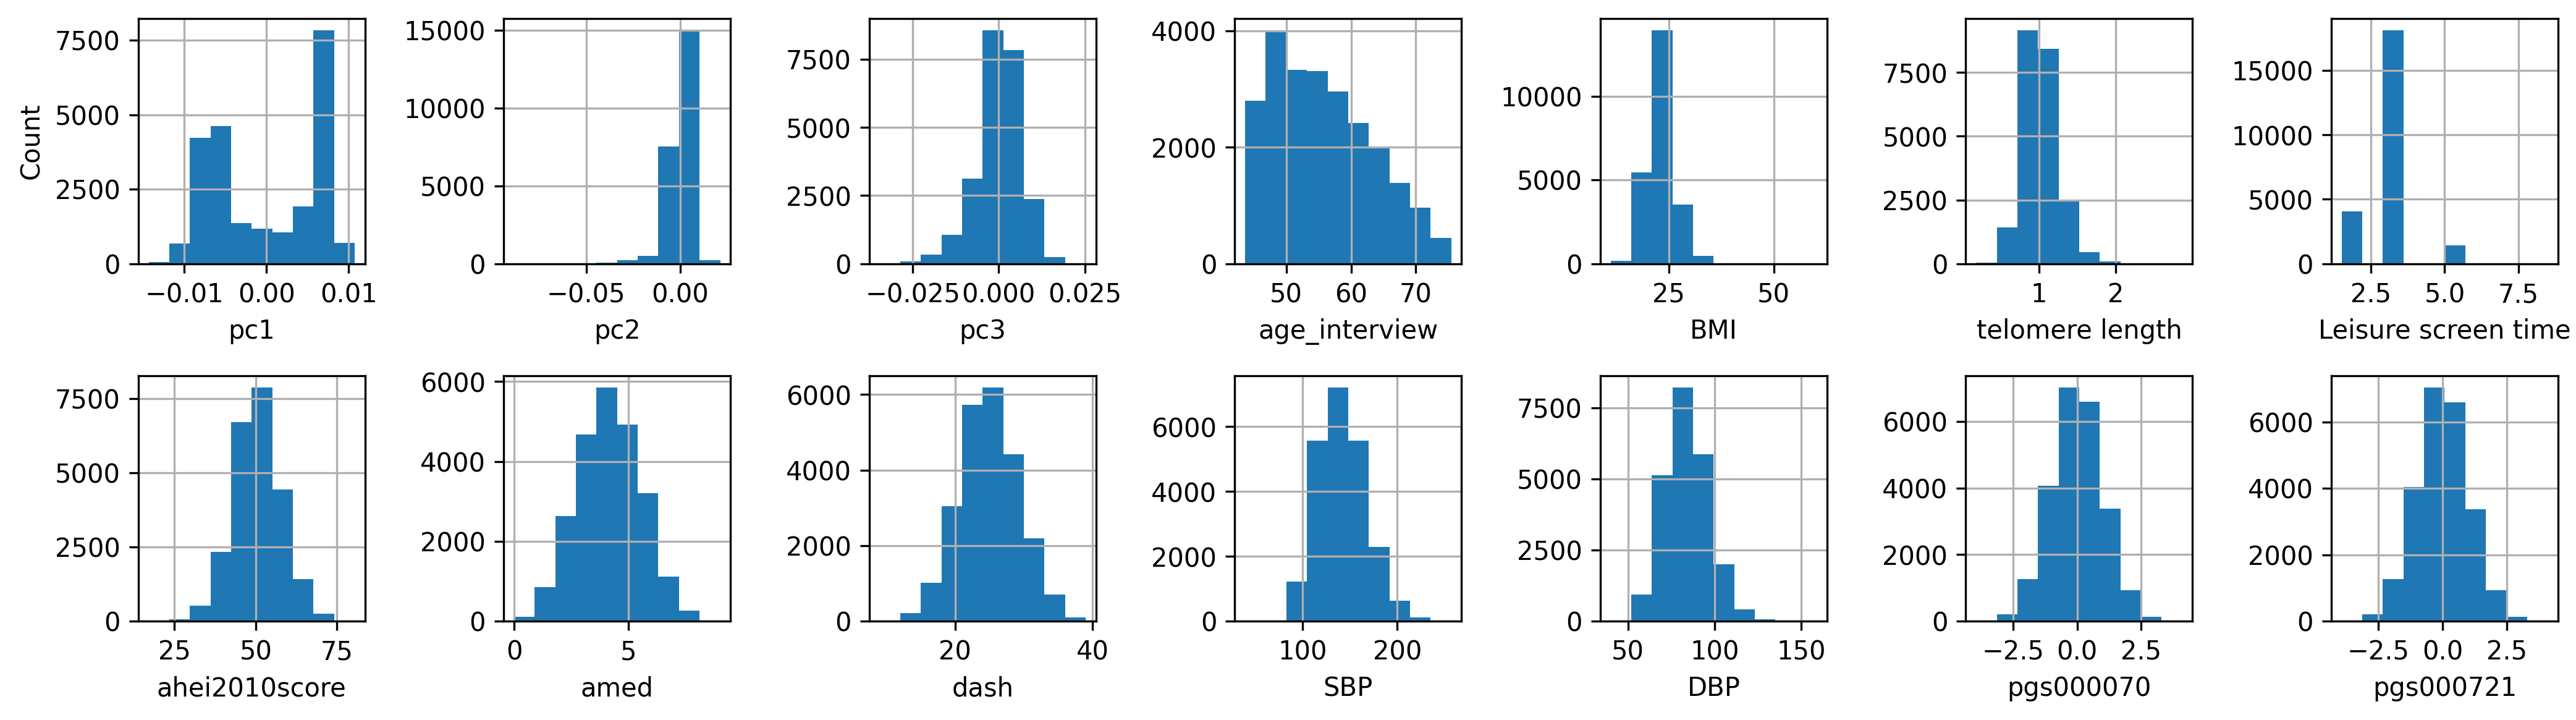

In [6]:
def show_continuous_features(df, continuous_cols, clean_col_names=None):
    from math import ceil
    nrows = 2
    ncols = ceil(len(continuous_cols)/2)
    size = 2
    fig, axes = plt.subplots(nrows, ncols, dpi=300, figsize=(size*ncols, size*nrows))
    axes = axes.flatten()
    axes[0].set_ylabel("Count")
    for i, col in enumerate(continuous_cols):
        df[col].hist(bins=10, ax=axes[i])
        axes[i].set_xlabel(clean_col_names[i] if clean_col_names else col) 
    for j in range(i+1, ncols*nrows):
        axes[j].set_axis_off()
    plt.tight_layout()
    
show_continuous_features(
    df,continuous_cols, 
)      

In [7]:
for col in categorical_cols + [target_col]:
    print(df[col].value_counts())

sex
2    13280
1    10342
Name: count, dtype: int64
alcohol_0_12
0    20805
1     2817
Name: count, dtype: int64
smoke_never(0)_ex(1)_current(2)
0    17005
2     4060
1     2557
Name: count, dtype: int64
shortsleepvsnormal
0.0    19902
1.0     2253
Name: count, dtype: int64
longsleepvsnormal
0.0    19902
1.0     1467
Name: count, dtype: int64
prevalent diabetes
0    21821
1     1801
Name: count, dtype: int64
lung cancer
0.0    22452
1.0      449
Name: count, dtype: int64


### Data Processing

#### Drop NA

In [8]:
def drop_na(df):
    df = df.copy()
    display(df.isna().sum())
    print(f"DataFrame Shape Before Dropping NA: {df.shape}")
    df = df.dropna()
    print(f"DataFrame Shape Before Dropping NA: {df.shape}")
    return df
df = drop_na(df)
display(df)

followup-time                       721
lung cancer                         721
pc1                                   0
pc2                                   0
pc3                                   0
sex                                   0
age_interview                         0
BMI                                   0
telomere length                    1502
smoke_never(0)_ex(1)_current(2)       0
Leisure screen time                   0
alcohol_0_12                          0
ahei2010score                         0
amed                                  0
dash                                  0
SBP                                 976
DBP                                 976
shortsleepvsnormal                 1467
longsleepvsnormal                  2253
prevalent diabetes                    0
pgs000070                             0
pgs000721                             0
dtype: int64

DataFrame Shape Before Dropping NA: (23622, 22)
DataFrame Shape Before Dropping NA: (17464, 22)


,followup-time,lung cancer,pc1,pc2,pc3,sex,age_interview,BMI,telomere length,smoke_never(0)_ex(1)_current(2),...,ahei2010score,amed,dash,SBP,DBP,shortsleepvsnormal,longsleepvsnormal,prevalent diabetes,pgs000070,pgs000721
serno,,,,,,,,,,,,,,,,,,,,,
821,14.795350,0.0,0.006581,0.007146,-0.011472,1,51.19507,23.14050,1.047413,0,...,53.43333,4,26,134.0,94.0,0.0,0.0,0,-1.500214,-3.760860
12879,14.485970,0.0,-0.000318,-0.004948,-0.003526,2,53.70842,25.00000,1.288483,0,...,54.99450,8,31,142.0,93.0,0.0,0.0,0,-1.822301,-3.583778
7874,15.570160,0.0,0.006716,-0.001151,0.004842,2,48.24367,23.11111,1.161449,0,...,51.87799,4,26,116.0,82.0,0.0,0.0,0,-0.756765,-3.525099
19514,11.863110,0.0,0.005967,0.000201,-0.004207,2,53.18823,23.51944,1.116684,0,...,54.93345,4,29,142.0,92.0,0.0,0.0,0,-1.445746,-3.434954
50821,5.867214,0.0,0.007496,-0.004633,0.011137,2,47.17865,25.55885,0.851400,0,...,51.55473,3,25,149.0,86.0,0.0,0.0,0,-1.010258,-3.434954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81866,13.232030,0.0,0.002233,0.004481,-0.004832,1,58.99795,22.05219,0.834438,0,...,44.70602,5,28,136.0,82.0,0.0,0.0,0,1.424645,3.499771
17958,12.169750,0.0,-0.007758,0.000059,0.000631,2,59.34018,21.64127,1.023038,0,...,54.45908,6,28,156.0,76.0,0.0,0.0,0,0.804766,3.552912
49562,11.173170,0.0,-0.009976,0.000312,0.005545,2,65.68652,19.97919,1.366731,0,...,53.76558,4,24,197.0,92.0,0.0,0.0,1,-1.155157,3.618489


In [9]:
for col in categorical_cols + [target_col]:
    print(df[col].value_counts())

sex
2    9595
1    7869
Name: count, dtype: int64
alcohol_0_12
0    15360
1     2104
Name: count, dtype: int64
smoke_never(0)_ex(1)_current(2)
0    12596
2     3016
1     1852
Name: count, dtype: int64
shortsleepvsnormal
0.0    17464
Name: count, dtype: int64
longsleepvsnormal
0.0    17464
Name: count, dtype: int64
prevalent diabetes
0    16232
1     1232
Name: count, dtype: int64
lung cancer
0.0    17140
1.0      324
Name: count, dtype: int64


#### Data Split

In [10]:
# Split data
def split_data_stratified(df, target_col, val_prop, test_prop, seed):
    np.random.seed(seed)
    df = df.copy()
    data_size = len(df)
    train_prop = 1 - val_prop - test_prop
    train_dfs, val_dfs, test_dfs = [], [], []
    # From each class, choose the same proportion of val and test
    for target, group_df in df.groupby(target_col):
        group_size = len(group_df)
        indices = np.array([i for i in range(group_size)])
        np.random.shuffle(indices)
        train_size, val_size = round(train_prop * group_size), round(val_prop * group_size)
        train_indices, val_indices, test_indices = (
            indices[:train_size], indices[train_size:train_size+val_size], indices[train_size+val_size:])
        train_dfs.append(group_df.iloc[train_indices])
        val_dfs.append(group_df.iloc[val_indices])
        test_dfs.append(group_df.iloc[test_indices])
    return dict(
        train_df=pd.concat(train_dfs), val_df=pd.concat(val_dfs), test_df=pd.concat(test_dfs)
    )

split_dict = split_data_stratified(df, target_col, val_prop=0.1, test_prop=0.1, seed=seed)
for label, cur_df in split_dict.items():
    print(label,":")
    print("- Total Number of Samples:", len(cur_df))
    print("- Class Distribution:", cur_df[target_col].value_counts()/len(cur_df))

train_df :
- Total Number of Samples: 13971
- Class Distribution: lung cancer
0.0    0.981462
1.0    0.018538
Name: count, dtype: float64
val_df :
- Total Number of Samples: 1746
- Class Distribution: lung cancer
0.0    0.981672
1.0    0.018328
Name: count, dtype: float64
test_df :
- Total Number of Samples: 1747
- Class Distribution: lung cancer
0.0    0.98111
1.0    0.01889
Name: count, dtype: float64


#### Data Normalisation

In [11]:
def normalise_data(train_df, val_df, test_df, continuous_cols):
    train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    train_df[continuous_cols] = scaler.fit_transform(train_df[continuous_cols])
    val_df[continuous_cols] = scaler.transform(val_df[continuous_cols])
    test_df[continuous_cols] = scaler.transform(test_df[continuous_cols])
    return dict(
        train_df=train_df, val_df=val_df, test_df=test_df
    ), scaler

split_dict_scaled, scaler = normalise_data(**split_dict, continuous_cols=continuous_cols)
for label, cur_df in split_dict_scaled.items():
    print(label,":")
    display(cur_df[continuous_cols].describe())

train_df :


,pc1,pc2,pc3,age_interview,BMI,telomere length,Leisure screen time,ahei2010score,amed,dash,SBP,DBP,pgs000070,pgs000721
count,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000
mean,0.572802,0.814772,0.577805,0.360508,0.231325,0.342438,0.252063,0.563336,0.516803,0.498589,0.480922,0.386048,0.479279,0.504271
std,0.259575,0.059926,0.108568,0.229426,0.067177,0.090261,0.130947,0.122037,0.193388,0.148980,0.116969,0.118756,0.127128,0.134166
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.316087,0.796922,0.519088,0.161888,0.187810,0.281174,0.285714,0.483387,0.375000,0.413793,0.396226,0.301887,0.393818,0.414011
50%,0.580982,0.821895,0.586312,0.326617,0.229642,0.333905,0.285714,0.561023,0.500000,0.482759,0.471698,0.377358,0.479086,0.503376
75%,0.839193,0.844893,0.647729,0.520968,0.264708,0.394879,0.285714,0.643522,0.625000,0.586207,0.556604,0.462264,0.564563,0.594577
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


val_df :


,pc1,pc2,pc3,age_interview,BMI,telomere length,Leisure screen time,ahei2010score,amed,dash,SBP,DBP,pgs000070,pgs000721
count,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000
mean,0.575177,0.814075,0.575051,0.362685,0.231524,0.341338,0.252250,0.565499,0.518399,0.498203,0.482767,0.388376,0.478042,0.501685
std,0.257206,0.060053,0.107117,0.230915,0.066018,0.088925,0.130007,0.121103,0.190412,0.149914,0.116250,0.116497,0.125828,0.133548
min,0.051883,0.215096,0.002443,0.018686,0.032521,0.055326,0.000000,0.132246,0.000000,0.034483,0.212264,0.037736,0.079122,0.081243
25%,0.321197,0.796923,0.517172,0.164428,0.187772,0.278675,0.285714,0.487902,0.375000,0.413793,0.396226,0.301887,0.392097,0.411179
50%,0.579589,0.821371,0.581455,0.329200,0.228578,0.332209,0.285714,0.564580,0.500000,0.482759,0.476415,0.386792,0.482420,0.500881
75%,0.840936,0.844714,0.643639,0.522755,0.264708,0.394589,0.285714,0.642492,0.625000,0.586207,0.561321,0.471698,0.562816,0.591586
max,0.959583,0.966221,0.902194,0.967192,0.583524,0.721572,1.000000,0.933177,1.000000,0.931034,0.943396,0.830189,0.887834,0.988456


test_df :


,pc1,pc2,pc3,age_interview,BMI,telomere length,Leisure screen time,ahei2010score,amed,dash,SBP,DBP,pgs000070,pgs000721
count,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000
mean,0.577669,0.813258,0.582951,0.359235,0.228227,0.341015,0.254068,0.564072,0.513380,0.493911,0.479580,0.383293,0.479984,0.502628
std,0.258916,0.059670,0.107653,0.230802,0.066452,0.089569,0.134395,0.124326,0.194262,0.152891,0.116321,0.119026,0.128283,0.134784
min,0.046964,0.272309,0.097151,0.000517,0.038236,0.085299,0.000000,0.138239,0.000000,0.068966,0.160377,0.037736,0.018124,0.072089
25%,0.317565,0.796879,0.526824,0.164169,0.187646,0.278690,0.285714,0.482191,0.375000,0.379310,0.396226,0.301887,0.393387,0.413298
50%,0.591665,0.821313,0.592635,0.327134,0.226789,0.334948,0.285714,0.561295,0.500000,0.482759,0.466981,0.367925,0.481518,0.502608
75%,0.842440,0.844244,0.655554,0.523035,0.260727,0.394405,0.285714,0.647242,0.625000,0.586207,0.551887,0.462264,0.565787,0.596636
max,0.972753,1.010338,0.892746,0.984931,0.802430,0.819657,1.000000,1.008307,1.125000,0.965517,0.896226,0.886792,0.966626,1.017083


In [12]:
# Save scaler
joblib.dump(scaler, fp_scaler_file) 

['../tree_featsel_checkpoints\\preprocessing\\lung_minmax_scaler.pickle']

#### Binarisation + One-Hot Encoding

In [13]:
def one_hot_encode_data(train_df, val_df, test_df, categorical_cols):
    train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
    
    # Binarise "Sex" col
    sex_prev_col_name = "sex"
    sex_new_col_name = "sex (0=Male, 1=Female)"
    train_df[sex_new_col_name] = train_df[sex_prev_col_name] - 1
    val_df[sex_new_col_name] = val_df[sex_prev_col_name] - 1
    test_df[sex_new_col_name] = test_df[sex_prev_col_name] - 1

    # One-Hot Encode "smoke_never" col
    smoke_prev_col_name =  'smoke_never(0)_ex(1)_current(2)'
    smoke_new_col_names = ["smoke_ex(1)", "smoke_current(2)"]
    from sklearn.preprocessing import OneHotEncoder
    encoder = OneHotEncoder(drop="first")
    train_df[smoke_new_col_names] = encoder.fit_transform(train_df[[smoke_prev_col_name]]).toarray()
    val_df[smoke_new_col_names] = encoder.transform(val_df[[smoke_prev_col_name]]).toarray()
    test_df[smoke_new_col_names] = encoder.transform(test_df[[smoke_prev_col_name]]).toarray()
    
    columns_to_drop = [sex_prev_col_name, smoke_prev_col_name]
    train_df = train_df.drop(columns_to_drop, axis=1)
    val_df = val_df.drop(columns_to_drop, axis=1)
    test_df = test_df.drop(columns_to_drop, axis=1)
    
    return dict(
        train_df=train_df, val_df=val_df, test_df=test_df
    ), encoder

split_dict_encoded, encoder = one_hot_encode_data(
    **split_dict_scaled, categorical_cols=categorical_cols)

for label, cur_df in split_dict_encoded.items():
    print(label,":")
    display(cur_df)

train_df :


,followup-time,lung cancer,pc1,pc2,pc3,age_interview,BMI,telomere length,Leisure screen time,alcohol_0_12,...,SBP,DBP,shortsleepvsnormal,longsleepvsnormal,prevalent diabetes,pgs000070,pgs000721,"sex (0=Male, 1=Female)",smoke_ex(1),smoke_current(2)
serno,,,,,,,,,,,,,,,,,,,,,
32103,4.490075,0.0,0.346978,0.828018,0.532263,0.332989,0.199744,0.343193,0.571429,0,...,0.363208,0.264151,0.0,0.0,0,0.370519,0.387133,0,0.0,1.0
39796,15.110200,0.0,0.845062,0.834600,0.459501,0.203221,0.232367,0.438748,0.285714,0,...,0.306604,0.330189,0.0,0.0,0,0.485255,0.427365,1,0.0,0.0
39853,12.769340,0.0,0.295198,0.807434,0.567708,0.492982,0.244506,0.206979,0.285714,1,...,0.386792,0.235849,0.0,0.0,0,0.373610,0.627232,0,0.0,1.0
47860,14.201230,0.0,0.867054,0.802131,0.828250,0.240765,0.302839,0.368996,0.285714,0,...,0.518868,0.471698,0.0,0.0,0,0.424395,0.461994,1,0.0,0.0
62061,11.767280,0.0,0.320282,0.867047,0.613349,0.120813,0.322521,0.254725,0.285714,0,...,0.613208,0.537736,0.0,0.0,0,0.374150,0.175665,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43701,5.440110,1.0,0.893678,0.789027,0.775450,0.593387,0.244607,0.343441,0.285714,0,...,0.433962,0.273585,0.0,0.0,0,0.574321,0.582598,1,0.0,0.0
38273,11.707050,1.0,0.827189,0.834744,0.520538,0.393180,0.268826,0.254435,0.285714,0,...,0.523585,0.471698,0.0,0.0,0,0.583100,0.451661,0,1.0,0.0
48777,10.206710,1.0,0.318882,0.826101,0.581695,0.505726,0.147226,0.479373,0.285714,0,...,0.570755,0.415094,0.0,0.0,0,0.654395,0.475348,0,0.0,1.0


val_df :


,followup-time,lung cancer,pc1,pc2,pc3,age_interview,BMI,telomere length,Leisure screen time,alcohol_0_12,...,SBP,DBP,shortsleepvsnormal,longsleepvsnormal,prevalent diabetes,pgs000070,pgs000721,"sex (0=Male, 1=Female)",smoke_ex(1),smoke_current(2)
serno,,,,,,,,,,,,,,,,,,,,,
70148,13.021220,0.0,0.851145,0.783676,0.582607,0.415052,0.221488,0.471171,0.285714,0,...,0.452830,0.377358,0.0,0.0,0,0.479525,0.587442,1,0.0,0.0
28889,15.219710,0.0,0.882320,0.808691,0.617177,0.205201,0.127262,0.352543,0.285714,0,...,0.415094,0.471698,0.0,0.0,0,0.324800,0.241561,1,0.0,0.0
78044,13.344290,0.0,0.374813,0.860904,0.561814,0.392922,0.301253,0.292051,0.285714,1,...,0.679245,0.566038,0.0,0.0,0,0.396649,0.545891,0,1.0,0.0
25667,15.233400,0.0,0.788068,0.913941,0.484375,0.276587,0.090479,0.340362,0.000000,1,...,0.386792,0.367925,0.0,0.0,0,0.484363,0.616639,0,0.0,1.0
63285,13.954830,0.0,0.282261,0.842600,0.658171,0.205459,0.213068,0.338856,0.000000,0,...,0.415094,0.245283,0.0,0.0,0,0.582459,0.761435,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26715,7.698836,1.0,0.820322,0.780506,0.515398,0.204857,0.221600,0.302194,0.285714,0,...,0.603774,0.584906,0.0,0.0,0,0.709072,0.435733,0,0.0,0.0
17971,4.585900,1.0,0.373329,0.811576,0.545052,0.492465,0.137772,0.304869,0.000000,0,...,0.632075,0.396226,0.0,0.0,0,0.759441,0.678599,0,0.0,1.0
49377,0.183436,1.0,0.894222,0.859363,0.685855,0.789202,0.154210,0.306668,0.285714,0,...,0.396226,0.283019,0.0,0.0,0,0.566129,0.374505,0,1.0,0.0


test_df :


,followup-time,lung cancer,pc1,pc2,pc3,age_interview,BMI,telomere length,Leisure screen time,alcohol_0_12,...,SBP,DBP,shortsleepvsnormal,longsleepvsnormal,prevalent diabetes,pgs000070,pgs000721,"sex (0=Male, 1=Female)",smoke_ex(1),smoke_current(2)
serno,,,,,,,,,,,,,,,,,,,,,
16863,14.798080,0.0,0.772394,0.796132,0.539263,0.291311,0.147226,0.328013,0.000000,1,...,0.632075,0.575472,0.0,0.0,0,0.195833,0.349611,0,1.0,0.0
65529,12.837780,0.0,0.808148,0.706182,0.642413,0.246362,0.145712,0.393485,0.285714,0,...,0.448113,0.320755,0.0,0.0,0,0.381910,0.542069,1,0.0,0.0
82080,13.021220,0.0,0.275918,0.837572,0.576133,0.436408,0.216764,0.453155,0.285714,1,...,0.542453,0.443396,0.0,0.0,0,0.543066,0.401361,0,0.0,1.0
78788,11.698840,0.0,0.564041,0.890506,0.422067,0.555757,0.102377,0.221097,0.000000,0,...,0.287736,0.141509,0.0,0.0,0,0.600610,0.309275,0,0.0,0.0
78534,13.111570,0.0,0.290435,0.848659,0.628588,0.435546,0.121438,0.209632,0.285714,0,...,0.443396,0.320755,0.0,0.0,0,0.329469,0.772978,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63965,2.277892,1.0,0.537310,0.883330,0.359396,0.053389,0.196229,0.303116,0.285714,0,...,0.396226,0.245283,0.0,0.0,0,0.403687,0.326380,1,0.0,0.0
58501,11.408620,1.0,0.295286,0.847879,0.598077,0.589081,0.283595,0.351923,0.285714,0,...,0.485849,0.358491,0.0,0.0,0,0.333323,0.384926,0,0.0,1.0
64796,4.049281,1.0,0.603831,0.829062,0.492725,0.920176,0.324877,0.279987,0.285714,0,...,0.514151,0.349057,0.0,0.0,0,0.508415,0.496713,1,1.0,0.0


In [14]:
# Save encoder
joblib.dump(encoder, fp_encoder_file) 

['../tree_featsel_checkpoints\\preprocessing\\lung_encoder.pickle']

In [15]:
# Check that continuous variables have been scaled
for label, cur_df in split_dict_encoded.items():
    print(label,":")
    display(cur_df[continuous_cols].describe())

train_df :


,pc1,pc2,pc3,age_interview,BMI,telomere length,Leisure screen time,ahei2010score,amed,dash,SBP,DBP,pgs000070,pgs000721
count,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000,13971.000000
mean,0.572802,0.814772,0.577805,0.360508,0.231325,0.342438,0.252063,0.563336,0.516803,0.498589,0.480922,0.386048,0.479279,0.504271
std,0.259575,0.059926,0.108568,0.229426,0.067177,0.090261,0.130947,0.122037,0.193388,0.148980,0.116969,0.118756,0.127128,0.134166
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.316087,0.796922,0.519088,0.161888,0.187810,0.281174,0.285714,0.483387,0.375000,0.413793,0.396226,0.301887,0.393818,0.414011
50%,0.580982,0.821895,0.586312,0.326617,0.229642,0.333905,0.285714,0.561023,0.500000,0.482759,0.471698,0.377358,0.479086,0.503376
75%,0.839193,0.844893,0.647729,0.520968,0.264708,0.394879,0.285714,0.643522,0.625000,0.586207,0.556604,0.462264,0.564563,0.594577
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


val_df :


,pc1,pc2,pc3,age_interview,BMI,telomere length,Leisure screen time,ahei2010score,amed,dash,SBP,DBP,pgs000070,pgs000721
count,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000,1746.000000
mean,0.575177,0.814075,0.575051,0.362685,0.231524,0.341338,0.252250,0.565499,0.518399,0.498203,0.482767,0.388376,0.478042,0.501685
std,0.257206,0.060053,0.107117,0.230915,0.066018,0.088925,0.130007,0.121103,0.190412,0.149914,0.116250,0.116497,0.125828,0.133548
min,0.051883,0.215096,0.002443,0.018686,0.032521,0.055326,0.000000,0.132246,0.000000,0.034483,0.212264,0.037736,0.079122,0.081243
25%,0.321197,0.796923,0.517172,0.164428,0.187772,0.278675,0.285714,0.487902,0.375000,0.413793,0.396226,0.301887,0.392097,0.411179
50%,0.579589,0.821371,0.581455,0.329200,0.228578,0.332209,0.285714,0.564580,0.500000,0.482759,0.476415,0.386792,0.482420,0.500881
75%,0.840936,0.844714,0.643639,0.522755,0.264708,0.394589,0.285714,0.642492,0.625000,0.586207,0.561321,0.471698,0.562816,0.591586
max,0.959583,0.966221,0.902194,0.967192,0.583524,0.721572,1.000000,0.933177,1.000000,0.931034,0.943396,0.830189,0.887834,0.988456


test_df :


,pc1,pc2,pc3,age_interview,BMI,telomere length,Leisure screen time,ahei2010score,amed,dash,SBP,DBP,pgs000070,pgs000721
count,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000
mean,0.577669,0.813258,0.582951,0.359235,0.228227,0.341015,0.254068,0.564072,0.513380,0.493911,0.479580,0.383293,0.479984,0.502628
std,0.258916,0.059670,0.107653,0.230802,0.066452,0.089569,0.134395,0.124326,0.194262,0.152891,0.116321,0.119026,0.128283,0.134784
min,0.046964,0.272309,0.097151,0.000517,0.038236,0.085299,0.000000,0.138239,0.000000,0.068966,0.160377,0.037736,0.018124,0.072089
25%,0.317565,0.796879,0.526824,0.164169,0.187646,0.278690,0.285714,0.482191,0.375000,0.379310,0.396226,0.301887,0.393387,0.413298
50%,0.591665,0.821313,0.592635,0.327134,0.226789,0.334948,0.285714,0.561295,0.500000,0.482759,0.466981,0.367925,0.481518,0.502608
75%,0.842440,0.844244,0.655554,0.523035,0.260727,0.394405,0.285714,0.647242,0.625000,0.586207,0.551887,0.462264,0.565787,0.596636
max,0.972753,1.010338,0.892746,0.984931,0.802430,0.819657,1.000000,1.008307,1.125000,0.965517,0.896226,0.886792,0.966626,1.017083


In [23]:
# Check that categorical variables correspond to pre-processed distributions
categorical_cols = [
    "sex (0=Male, 1=Female)", 'alcohol_0_12', "smoke_ex(1)", "smoke_current(2)",
    'prevalent diabetes', # 'shortsleepvsnormal', 'longsleepvsnormal', 
]
_ = get_col_types(split_dict_encoded["train_df"], categorical_cols, target_col, exclude_col)

5 Categorical Columns: ['sex (0=Male, 1=Female)', 'alcohol_0_12', 'smoke_ex(1)', 'smoke_current(2)', 'prevalent diabetes']
16 Continuous Columns: ['pc1', 'pc2', 'pc3', 'age_interview', 'BMI', 'telomere length', 'Leisure screen time', 'ahei2010score', 'amed', 'dash', 'SBP', 'DBP', 'shortsleepvsnormal', 'longsleepvsnormal', 'pgs000070', 'pgs000721']
Target Column: lung cancer


In [24]:
testing_df = pd.concat(list(split_dict_encoded.values()))
for col in categorical_cols + [target_col]:
    print(testing_df[col].value_counts())

sex (0=Male, 1=Female)
1    9595
0    7869
Name: count, dtype: int64
alcohol_0_12
0    15360
1     2104
Name: count, dtype: int64
smoke_ex(1)
0.0    15612
1.0     1852
Name: count, dtype: int64
smoke_current(2)
0.0    14448
1.0     3016
Name: count, dtype: int64
prevalent diabetes
0    16232
1     1232
Name: count, dtype: int64
lung cancer
0.0    17140
1.0      324
Name: count, dtype: int64


#### Oversample Data

In [25]:
def oversample_data(train_df, val_df, test_df, target_col):
    from imblearn.over_sampling import SMOTE
    train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
    oversample = SMOTE(random_state=seed)
    feature_cols = [col for col in train_df.columns if col != target_col]
    X, y = oversample.fit_resample(train_df[feature_cols], train_df[target_col])
    train_df = pd.DataFrame(X, columns=feature_cols)
    train_df[target_col] = y
    return dict(
        train_df=train_df, val_df=val_df, test_df=test_df
    )

split_dict_oversampled = oversample_data(
    **split_dict_encoded, target_col=target_col)
split_dict_oversampled["train_df"][target_col].value_counts()

lung cancer
0.0    13712
1.0    13712
Name: count, dtype: int64

In [26]:
feat_cols_w_pc = continuous_cols + categorical_cols
print(f"{len(feat_cols_w_pc)} Feature Columns With PCs: {feat_cols_w_pc}")
feat_cols_wo_pc = continuous_cols + categorical_cols
feat_cols_wo_pc = [e for e in feat_cols_wo_pc if ("pc" not in e)]
print(f"{len(feat_cols_wo_pc)} Feature Columns Without PCs: {feat_cols_wo_pc}")

19 Feature Columns With PCs: ['pc1', 'pc2', 'pc3', 'age_interview', 'BMI', 'telomere length', 'Leisure screen time', 'ahei2010score', 'amed', 'dash', 'SBP', 'DBP', 'pgs000070', 'pgs000721', 'sex (0=Male, 1=Female)', 'alcohol_0_12', 'smoke_ex(1)', 'smoke_current(2)', 'prevalent diabetes']
16 Feature Columns Without PCs: ['age_interview', 'BMI', 'telomere length', 'Leisure screen time', 'ahei2010score', 'amed', 'dash', 'SBP', 'DBP', 'pgs000070', 'pgs000721', 'sex (0=Male, 1=Female)', 'alcohol_0_12', 'smoke_ex(1)', 'smoke_current(2)', 'prevalent diabetes']


### Training & Tuning Functions

In [51]:
def evaluate(Y, Y_pred_prob, label):
    from sklearn.metrics import log_loss, accuracy_score, roc_auc_score
    Y_pred = np.argmax(Y_pred_prob, axis=-1)
    return {
        f"{label} Accuracy": accuracy_score(Y, Y_pred),
        f"{label} AUC": roc_auc_score(Y, Y_pred_prob[:, 1]),
        f"{label} Loss": log_loss(Y, Y_pred_prob[:, 1]),
    }

def tune_model(
    train_df, val_df, test_df, 
    param_grid, 
    feat_cols, target_col, seed=seed, verbose=True
):
    # from sklearn.ensemble import RandomForestClassifier
    from imblearn.ensemble import BalancedRandomForestClassifier
    from sklearn.model_selection import ParameterGrid
    
    train_df, val_df = train_df.copy(), val_df.copy()
    
    # Process data
    train_X, train_Y = train_df[feat_cols].values, train_df[target_col].values
    valid_X, valid_Y = val_df[feat_cols].values, val_df[target_col].values
    test_X, test_Y = test_df[feat_cols].values, test_df[target_col].values
    
    df_list = []
    grid = list(ParameterGrid(param_grid))
    best_val_auc = None
    # Tune model
    pbar = tqdm(grid, disable=not verbose, total=len(grid))
    for param_dict in pbar:
        if best_val_auc is None:
            pbar.set_description(f"Params: {param_dict}")
        else:
            pbar.set_description(f"Params: {param_dict}, Best Val AUC: {best_val_auc:.5f}")
        # clf = RandomForestClassifier(random_state=seed, n_estimators=n_estimators)
        # https://machinelearningmastery.com/bagging-and-random-forest-for-imbalanced-classification/
        clf = BalancedRandomForestClassifier(
            random_state=seed, **param_dict,
            sampling_strategy="all", replacement=True, bootstrap=False
        )
        start = time.time()
        clf.fit(train_X, train_Y)
        end = time.time()
        train_Y_pred = clf.predict_proba(train_X)
        valid_Y_pred = clf.predict_proba(valid_X)
        test_Y_pred = clf.predict_proba(test_X)
        
        results_dict = param_dict.copy()
        results_dict.update(evaluate(train_Y, train_Y_pred, label="Training"))
        valid_perf_dict = evaluate(valid_Y, valid_Y_pred, label="Validation")
        results_dict.update(valid_perf_dict)
        results_dict.update(evaluate(test_Y, test_Y_pred, label="Testing"))
        results_dict["Train Time/s"] = end-start
        df_list.append(results_dict)
        if ((best_val_auc is None) or (valid_perf_dict["Validation AUC"] > best_val_auc)):
            best_val_auc = valid_perf_dict["Validation AUC"]
    tuning_df = pd.DataFrame(df_list)
    best_index = tuning_df["Validation AUC"].idxmax()
    tuning_df["Best Hyperparamter"] = False
    tuning_df.loc[best_index, "Best Hyperparamter"] = True
    best_param_dict = grid[best_index]
    return best_param_dict, tuning_df


def get_predictions(train_df, val_df, test_df, feat_cols, target_col, clf, verbose=True):
    train_df, val_df = train_df.copy(), val_df.copy()
    from sklearn.metrics import log_loss, accuracy_score, roc_auc_score, recall_score, precision_score, f1_score
    train_X, train_Y = train_df[feat_cols].values, train_df[target_col].values
    valid_X, valid_Y = val_df[feat_cols].values, val_df[target_col].values
    test_X, test_Y = test_df[feat_cols].values, test_df[target_col].values
    if verbose:
        print("2. Predicting...")
    pred_col = f"{target_col}_pred"
    start = time.time()
    train_Y_pred = clf.predict_proba(train_X)
    train_df[pred_col] = train_Y_pred[:, 1]
    if verbose:
        print(f" - Prediction for Training Set Took {time.time()-start}s")
    start = time.time()
    valid_Y_pred = clf.predict_proba(valid_X)
    val_df[pred_col] = valid_Y_pred[:, 1]
    if verbose:
        print(f" - Prediction for Validation Set Took {time.time()-start}s")
    start = time.time()
    test_Y_pred = clf.predict_proba(test_X)
    test_df[pred_col] = test_Y_pred[:, 1]
    if verbose:
        print(f" - Prediction for Test Set Took {time.time()-start}s")

    # Evaluate Model
    if verbose:
        print("3. Evaluating...")
    perf_df = pd.DataFrame(dict(
        AUC = [
            roc_auc_score(train_Y, train_df[pred_col]), 
            roc_auc_score(valid_Y, val_df[pred_col]), 
            roc_auc_score(test_Y, test_df[pred_col])],
        Accuracy = [
            accuracy_score(train_Y, train_df[pred_col]>0.5), 
            accuracy_score(valid_Y, val_df[pred_col]>0.5), 
            accuracy_score(test_Y, test_df[pred_col]>0.5)],
        Loss = [
            log_loss(train_Y, train_df[pred_col]), 
            log_loss(valid_Y, val_df[pred_col]), 
            log_loss(test_Y, test_df[pred_col])], 
        Recall = [
            recall_score(train_Y, train_df[pred_col]>0.5),
            recall_score(valid_Y, val_df[pred_col]>0.5), 
            recall_score(test_Y, test_df[pred_col]>0.5)],
        Precision = [
            precision_score(train_Y, train_df[pred_col]>0.5),
            precision_score(valid_Y, val_df[pred_col]>0.5), 
            precision_score(test_Y, test_df[pred_col]>0.5)],
        F1_Score = [
            f1_score(train_Y, train_df[pred_col]>0.5),
            f1_score(valid_Y, val_df[pred_col]>0.5), 
            f1_score(test_Y, test_df[pred_col]>0.5)],
    ), index=["Train", "Valid", "Test"])
    
    return dict(
        train_df=train_df, val_df=val_df, test_df=test_df
    ), perf_df

def buffered_shap(explainer, matrix, chunksize, pred):
    def process_shap(shap, pred):
        pred = (pred > 0.50).values.astype(int)
        # (2, 160, 14) -> (160, 2, 14)
        shap = np.transpose(shap, (1, 0, 2))
        # Get Shap of Predicted
        shap = shap[np.arange(len(shap)), pred]
        return shap
    
    from math import ceil
    all_exp = []
    matrix_len = len(matrix)
    num_chunks = ceil(matrix_len/chunksize)
    for chunk_i in tqdm(range(num_chunks), total=num_chunks):
        start = chunk_i*chunksize
        end = (chunk_i+1)*chunksize
        if end < matrix_len:
            matrix_chunk = matrix[chunk_i*chunksize:(chunk_i+1)*chunksize]
            pred_chunk = pred[chunk_i*chunksize:(chunk_i+1)*chunksize]
        else:
            matrix_chunk = matrix[chunk_i*chunksize:]
            pred_chunk = pred[chunk_i*chunksize:]
        shap_chunk = explainer.shap_values(matrix_chunk)
        exp_chunk = process_shap(shap_chunk, pred_chunk)
        all_exp.append(exp_chunk)
    return np.vstack(all_exp)

def get_shap_values(train_df, val_df, test_df, feat_cols, target_col, clf, chunksize=64):
    train_df, val_df = train_df.copy(), val_df.copy()
    train_X, train_Y = train_df[feat_cols].values, train_df[target_col].values
    valid_X, valid_Y = val_df[feat_cols].values, val_df[target_col].values
    test_X, test_Y = test_df[feat_cols].values, test_df[target_col].values
    pred_col = f"{target_col}_pred"
    # Get Shap
    print("4. Getting Shap Values...")
    shap_cols = [f"{col}_shap" for col in feat_cols]
    print(" - Instantiating Explainer...")
    explainer = shap.TreeExplainer(clf)
    
    # (2, 160, 14)
    print("4. Getting Explanations...")
    # start = time.time()
    # train_df[shap_cols] = buffered_shap(
    #     explainer=explainer, matrix=train_X, chunksize=64, pred=train_df[pred_col]
    # )
    # print(f" - Explanations for Training Set Took {time.time()-start}s")
    # start = time.time()
    # val_df[shap_cols] = buffered_shap(
    #     explainer=explainer, matrix=valid_X, chunksize=chunksize, pred=val_df[pred_col]
    # )
    # print(f" - Explanations for Validation Set Took {time.time()-start}s")
    start = time.time()
    test_df[shap_cols]=buffered_shap(
        explainer=explainer, matrix=test_X, chunksize=64, pred=test_df[pred_col]
    )
    print(f" - Explanations for Test Set Took {time.time()-start}s")
    return dict(
        train_df=train_df, val_df=val_df, test_df=test_df
    )

def train_model(
    train_df, val_df, test_df, feat_cols, target_col, param_dict, seed=seed, verbose=True):
    from imblearn.ensemble import BalancedRandomForestClassifier
    train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
    # Process data
    train_X, train_Y = train_df[feat_cols].values, train_df[target_col].values
    valid_X, valid_Y = val_df[feat_cols].values, val_df[target_col].values
    test_X, test_Y = test_df[feat_cols].values, test_df[target_col].values
    
    # Train Model
    if verbose:
        print("1. Training The Model...")
    clf = BalancedRandomForestClassifier(
            random_state=seed, **param_dict, sampling_strategy="all", replacement=True, bootstrap=False)
    start = time.time()
    clf.fit(train_X, train_Y)
    if verbose:
        print(f" - Training Took {time.time()-start}s")
    
    return clf

def format_results(train_df, val_df, test_df, target_col, scaler, continuous_cols):
    train_df, val_df = train_df.copy(), val_df.copy()
    print("6. Generating Outputs...")
    pred_col = f"{target_col}_pred"
    pred_df = test_df.copy()
    # pred_df = pd.concat([train_df, val_df, test_df])
    pred_df[continuous_cols] = scaler.inverse_transform(pred_df[continuous_cols])
    pred_df["split"] = ["test"]*len(test_df)
    # pred_df["split"] = ["train"]*len(train_df) + ["valid"]*len(val_df)+ ["test"]*len(test_df)
    pred_bin_col = f"{target_col}_pred_bin"
    pred_df[pred_bin_col] = (pred_df[pred_col] > 0.5).astype(int)
    return pred_df

### Get Best Number of Features

In [28]:
# Feature Selection
# https://medium.com/@hertan06/which-features-to-use-in-your-model-350630a1e31c
def get_feat_sel_df(train_df, feat_cols, target_col, categorical_cols):
    from sklearn.feature_selection import mutual_info_classif
    categorical_indices = [i for i, col in enumerate(feat_cols) if col in categorical_cols]
    # print(np.array(feat_cols)[categorical_indices])
    mi = mutual_info_classif(train_df[feat_cols].values, train_df[target_col].values, copy=True, random_state=seed)
    featsel_df = pd.DataFrame({"Feature":feat_cols, "Estimated Mutual Information":mi})
    featsel_df = featsel_df.sort_values(by="Estimated Mutual Information", ascending=False)
    return featsel_df

def feature_selection(train_df, feat_cols, target_col, categorical_cols, top_k, show_featsel_df=True):
    featsel_df = get_feat_sel_df(train_df, feat_cols, target_col, categorical_cols)
    if show_featsel_df:
        display(featsel_df)
    return featsel_df["Feature"].iloc[:top_k].values

def get_best_number_of_features(
    split_dict_encoded, split_dict_oversampled, all_feat_cols, target_col, categorical_cols
):
    df_list = []
    feat_sel_df = get_feat_sel_df(
        train_df=split_dict_oversampled["train_df"], 
        feat_cols=all_feat_cols, target_col=target_col, categorical_cols=categorical_cols)
    num_feat = len(feat_sel_df)
    all_features = feat_sel_df["Feature"].values

    best_val_auc = 0
    best_k = -1
    with tqdm(range(1,num_feat+1), total=num_feat, position=0, leave=True) as pbar:
        for k in pbar:
            best_feat_oversampled = all_features[:k]
            print(f"Number of Features: {k}, Selected Features: {best_feat_oversampled}")
            best_estimators, _ = tune_model(
                **split_dict_encoded,
                feat_cols=best_feat_oversampled, 
                target_col=target_col,
                param_grid={"n_estimators":[50, 100,200, 300, 400, 500, 600, 700]}, 
                seed=seed, verbose=False
            )
            print(f"   - Optimal Number of Estimators: {best_estimators}")
            # display(crc_tuning_df_w_pc)
            # crc_tuning_df_w_pc.to_csv(fp_crc_tuning_w_pc_file)
            clf = train_model(
                **split_dict_encoded, feat_cols=best_feat_oversampled, target_col=target_col, 
                param_dict=best_estimators, seed=seed, verbose=False
            )
            _, perf_df_w_pc = get_predictions(
                **split_dict_encoded, feat_cols=best_feat_oversampled, target_col=target_col,
                clf=clf, verbose=False
            )
            # display(crc_perf_df_w_pc)
            val_auc = perf_df_w_pc.loc["Valid", "AUC"]
            test_auc = perf_df_w_pc.loc["Test", "AUC"]
            df_list.append({
                "K":k, "Valid AUC":val_auc, "Test AUC":test_auc, "Num Estimators":best_estimators
            })
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_k = k
                
            pbar.set_description(f"Best AUC: {best_val_auc:.5f}, Best k: {best_k}, Latest AUC: {val_auc:.5f}")
    df = pd.DataFrame(df_list)
    best_val_auc = df["Valid AUC"].max()
    df["Best K"] = df["Valid AUC"] == best_val_auc
    return df

In [30]:
num_feat_df = get_best_number_of_features(
    split_dict_encoded=split_dict_encoded, 
    split_dict_oversampled=split_dict_oversampled, 
    all_feat_cols=feat_cols_wo_pc, 
    target_col=target_col, categorical_cols=categorical_cols
)
display(num_feat_df)

  0%|          | 0/16 [00:00<?, ?it/s]

Number of Features: 1, Selected Features: ['SBP']
   - Optimal Number of Estimators: {'n_estimators': 50}
Number of Features: 2, Selected Features: ['SBP' 'DBP']
   - Optimal Number of Estimators: {'n_estimators': 50}
Number of Features: 3, Selected Features: ['SBP' 'DBP' 'dash']
   - Optimal Number of Estimators: {'n_estimators': 50}
Number of Features: 4, Selected Features: ['SBP' 'DBP' 'dash' 'BMI']
   - Optimal Number of Estimators: {'n_estimators': 50}
Number of Features: 5, Selected Features: ['SBP' 'DBP' 'dash' 'BMI' 'pgs000721']
   - Optimal Number of Estimators: {'n_estimators': 50}
Number of Features: 6, Selected Features: ['SBP' 'DBP' 'dash' 'BMI' 'pgs000721' 'pgs000070']
   - Optimal Number of Estimators: {'n_estimators': 700}
Number of Features: 7, Selected Features: ['SBP' 'DBP' 'dash' 'BMI' 'pgs000721' 'pgs000070' 'amed']
   - Optimal Number of Estimators: {'n_estimators': 700}
Number of Features: 8, Selected Features: ['SBP' 'DBP' 'dash' 'BMI' 'pgs000721' 'pgs000070' 'a

,K,Valid AUC,Test AUC,Num Estimators,Best K
0,1,0.518178,0.533203,{'n_estimators': 50},False
1,2,0.468139,0.591881,{'n_estimators': 50},False
2,3,0.575636,0.547267,{'n_estimators': 50},False
3,4,0.592237,0.539868,{'n_estimators': 50},False
4,5,0.641929,0.579497,{'n_estimators': 50},False
5,6,0.633068,0.551377,{'n_estimators': 700},False
6,7,0.644828,0.531691,{'n_estimators': 700},False
7,8,0.660945,0.562047,{'n_estimators': 700},False
8,9,0.701666,0.590326,{'n_estimators': 300},False
9,10,0.794997,0.726424,{'n_estimators': 700},False


In [31]:
num_feat_df.to_csv("num_feat_df_wo_pc.csv")

In [49]:
num_feat_df = get_best_number_of_features(
    split_dict_encoded=split_dict_encoded, 
    split_dict_oversampled=split_dict_oversampled, 
    all_feat_cols=feat_cols_w_pc, 
    target_col=target_col, categorical_cols=continuous_cols
)
display(num_feat_df)

  0%|          | 0/21 [00:00<?, ?it/s]

Number of Features: 1, Selected Features: ['SBP']
   - Optimal Number of Estimators: {'n_estimators': 50}
Number of Features: 2, Selected Features: ['SBP' 'DBP']
   - Optimal Number of Estimators: {'n_estimators': 50}
Number of Features: 3, Selected Features: ['SBP' 'DBP' 'dash']
   - Optimal Number of Estimators: {'n_estimators': 50}
Number of Features: 4, Selected Features: ['SBP' 'DBP' 'dash' 'BMI']
   - Optimal Number of Estimators: {'n_estimators': 50}
Number of Features: 5, Selected Features: ['SBP' 'DBP' 'dash' 'BMI' 'pgs000721']
   - Optimal Number of Estimators: {'n_estimators': 50}
Number of Features: 6, Selected Features: ['SBP' 'DBP' 'dash' 'BMI' 'pgs000721' 'pgs000070']
   - Optimal Number of Estimators: {'n_estimators': 700}
Number of Features: 7, Selected Features: ['SBP' 'DBP' 'dash' 'BMI' 'pgs000721' 'pgs000070' 'amed']
   - Optimal Number of Estimators: {'n_estimators': 700}
Number of Features: 8, Selected Features: ['SBP' 'DBP' 'dash' 'BMI' 'pgs000721' 'pgs000070' 'a

,K,Valid AUC,Test AUC,Num Estimators,Best K
0,1,0.518178,0.533203,{'n_estimators': 50},False
1,2,0.468139,0.591881,{'n_estimators': 50},False
2,3,0.575636,0.547267,{'n_estimators': 50},False
3,4,0.592237,0.539868,{'n_estimators': 50},False
4,5,0.641929,0.579497,{'n_estimators': 50},False
5,6,0.633068,0.551377,{'n_estimators': 700},False
6,7,0.644828,0.531691,{'n_estimators': 700},False
7,8,0.660945,0.562047,{'n_estimators': 700},False
8,9,0.701666,0.590326,{'n_estimators': 300},False
9,10,0.794997,0.726424,{'n_estimators': 700},False


In [34]:
# best_feat_w_pc_encoded = feature_selection(
#     train_df=crc_split_dict_encoded["train_df"], 
#     feat_cols=crc_feat_cols_w_pc, 
#     target_col=crc_target_col_new, 
#     categorical_cols=crc_categorical_cols_new,
#     top_k=15
# )

best_feat_wo_pc_oversampled = feature_selection(
    train_df=split_dict_oversampled["train_df"], 
    feat_cols=feat_cols_wo_pc, 
    target_col=target_col, 
    categorical_cols=categorical_cols,
    top_k=15
)

,Feature,Estimated Mutual Information
7,SBP,0.596470
8,DBP,0.577680
6,dash,0.553666
1,BMI,0.473921
10,pgs000721,0.464877
9,pgs000070,0.451216
5,amed,0.405941
3,Leisure screen time,0.162419
0,age_interview,0.090478
14,smoke_current(2),0.078705


In [35]:
print(best_feat_w_pc_oversampled)

['SBP' 'DBP' 'dash' 'BMI' 'pgs000721' 'pgs000070' 'amed'
 'Leisure screen time' 'age_interview' 'smoke_current(2)'
 'sex (0=Male, 1=Female)' 'pc1' 'ahei2010score' 'pc2' 'prevalent diabetes']


### Get Best Max Depth

In [40]:
best_param_max_depth_wo_pc, max_depth_tuning_df_wo_pc = tune_model(
    **split_dict_encoded,
    feat_cols=best_feat_wo_pc_oversampled, 
    target_col=target_col,
    seed=seed,
    param_grid=dict(
        n_estimators = [50, 100,200, 300, 400, 500, 600, 700],
        max_depth = [5, 10, 20, 30, 40]
    ), 
) # 0.813603	

  0%|          | 0/40 [00:00<?, ?it/s]

In [42]:
max_depth_tuning_df_wo_pc

,max_depth,n_estimators,Training Accuracy,Training AUC,Training Loss,Validation Accuracy,Validation AUC,Validation Loss,Testing Accuracy,Testing AUC,Testing Loss,Train Time/s,Best Hyperparamter
0,5,50,0.741250,0.847070,0.550090,0.742268,0.805809,0.550973,0.735547,0.748099,0.563712,0.250847,False
1,5,100,0.759573,0.852380,0.548764,0.766323,0.801415,0.548936,0.746422,0.740214,0.563261,0.474985,False
2,5,200,0.773531,0.855407,0.547178,0.782932,0.803767,0.547940,0.755581,0.739631,0.562685,0.910109,False
3,5,300,0.776251,0.854417,0.548543,0.782360,0.803749,0.549712,0.752147,0.738376,0.564193,1.431991,False
4,5,400,0.777253,0.854796,0.546900,0.785796,0.802655,0.548037,0.757298,0.735847,0.562484,1.811883,False
5,5,500,0.776609,0.855049,0.546787,0.785223,0.802855,0.547834,0.755009,0.735688,0.562123,2.308338,False
6,5,600,0.776108,0.854366,0.547584,0.779496,0.802454,0.548359,0.756726,0.735936,0.562867,2.672866,False
7,5,700,0.774032,0.854422,0.548191,0.778351,0.801178,0.549210,0.753291,0.735794,0.563719,3.104308,False
8,10,50,0.828502,0.968171,0.450221,0.818442,0.815836,0.460182,0.801946,0.734256,0.475260,0.248003,True
9,10,100,0.836948,0.975656,0.449139,0.824742,0.809236,0.461841,0.803091,0.724921,0.477360,0.497059,False


In [45]:
print(best_param_max_depth_wo_pc)

{'max_depth': 10, 'n_estimators': 50}


In [48]:
max_depth_tuning_df_wo_pc[
    max_depth_tuning_df_wo_pc.groupby("max_depth")["Validation AUC"].transform(max) == max_depth_tuning_df_wo_pc["Validation AUC"]
]

C:\Users\WLR\AppData\Local\Temp\ipykernel_32100\3072521796.py:2: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  max_depth_tuning_df_wo_pc.groupby("max_depth")["Validation AUC"].transform(max) == max_depth_tuning_df_wo_pc["Validation AUC"]


,max_depth,n_estimators,Training Accuracy,Training AUC,Training Loss,Validation Accuracy,Validation AUC,Validation Loss,Testing Accuracy,Testing AUC,Testing Loss,Train Time/s,Best Hyperparamter
0,5,50,0.741250,0.847070,0.550090,0.742268,0.805809,0.550973,0.735547,0.748099,0.563712,0.250847,False
8,10,50,0.828502,0.968171,0.450221,0.818442,0.815836,0.460182,0.801946,0.734256,0.475260,0.248003,True
20,20,400,0.862572,0.995165,0.420592,0.851088,0.813512,0.437601,0.828849,0.735441,0.453153,1.996015,False
29,30,500,0.861857,0.995528,0.421204,0.854525,0.813603,0.438108,0.831712,0.736387,0.454079,2.449512,False
37,40,500,0.861857,0.995528,0.421204,0.854525,0.813603,0.438108,0.831712,0.736387,0.454079,2.550082,False


In [52]:
best_param_max_depth_w_pc = {'max_depth': 10, 'n_estimators': 50}
clf_wo_pc = train_model(
    **split_dict_encoded, feat_cols=best_feat_wo_pc_oversampled, target_col=target_col, 
    param_dict = best_param_max_depth_wo_pc, seed=seed
)
pred_dict_wo_pc, perf_df_wo_pc = get_predictions(
    **split_dict_encoded, feat_cols=best_feat_wo_pc_oversampled, target_col=target_col, 
    clf=clf_wo_pc)
display(perf_df_wo_pc)

1. Training The Model...
 - Training Took 0.25208520889282227s
2. Predicting...
 - Prediction for Training Set Took 0.05051684379577637s
 - Prediction for Validation Set Took 0.009999990463256836s
 - Prediction for Test Set Took 0.009999990463256836s
3. Evaluating...


,AUC,Accuracy,Loss,Recall,Precision,F1_Score
Train,0.968171,0.828502,0.450221,0.972973,0.095418,0.173793
Valid,0.815836,0.818442,0.460182,0.687500,0.066869,0.121884
Test,0.734256,0.801946,0.475260,0.606061,0.056657,0.103627


### Information for Survey

In [63]:
class ConditionalGaussianDistribution:
    def __init__(self, Y, X):
        self.Y = Y # Assume shape = (num_samples, num_output)
        self.X = X # Assume shape = (num_samples, num_inputs)
        self.YX = np.concatenate((Y, X), axis=-1) # Assume shape = (num_samples, num_output+num_inputs)
        self.num_Y = self.Y.shape[1]
        self.num_X = self.X.shape[1]

        # Fitting
        self.esti_mean_YX = np.mean(self.YX, axis = 0) # (num_output+num_inputs,)
        self.esti_covariance_matrix_YX = np.cov(self.YX.T, ddof=1) # (num_output+num_inputs, num_output+num_inputs)
        
        # Useful stats
        self.mu_Y = self.esti_mean_YX[:self.num_Y]
        self.mu_X = self.esti_mean_YX[self.num_Y:]
        self.cov_XX = self.esti_covariance_matrix_YX[self.num_Y:, self.num_Y:]
        self.cov_YY = self.esti_covariance_matrix_YX[:self.num_Y, :self.num_Y]
        self.cov_YX = self.esti_covariance_matrix_YX[:self.num_Y, self.num_Y:]
        self.cov_XY = self.esti_covariance_matrix_YX[self.num_Y:, :self.num_Y]
        
    def get_conditional_mean(self, alpha):
        # alpha = (num_samples, self.num_X)
        return (
            self.mu_Y + 
            np.linalg.multi_dot((
                self.cov_YX,
                np.linalg.inv(self.cov_XX),
                (alpha - self.mu_X).T))
        ).flatten()
        
    def get_conditional_cov(self):
        return (
            self.cov_YY - 
            np.linalg.multi_dot((
                self.cov_YX,
                np.linalg.inv(self.cov_XX), 
                self.cov_XY))
        ).flatten()[0]

class TruncatedConditionalGaussianDistribution:
    def __init__(self, Y, X, Y_Range):
        self.cgd = ConditionalGaussianDistribution(Y, X)
        self.Y_lb, self.Y_ub = Y_Range[0], Y_Range[1]

        # https://en.wikipedia.org/wiki/Truncated_normal_distribution
        self.cond_std = np.sqrt(self.cgd.get_conditional_cov())
        
    def get_conditional_mean(self, alpha):
        from scipy.stats import norm
        cond_mean = self.cgd.get_conditional_mean(alpha)
        alpha = (self.Y_lb-cond_mean)/self.cond_std
        beta = (self.Y_ub-cond_mean)/self.cond_std
        pdf_over_cdf = (
            (norm.pdf(beta)-norm.pdf(alpha))/
            (norm.cdf(beta)-norm.cdf(alpha))
        )
        mean_bias = -self.cond_std*pdf_over_cdf
        return cond_mean+mean_bias
        
    def get_conditional_cov(self, alpha):
        from scipy.stats import norm
        cond_mean = self.cgd.get_conditional_mean(alpha)
        cond_cov = self.cgd.get_conditional_cov()
        alpha = (self.Y_lb-cond_mean)/self.cond_std
        beta = (self.Y_ub-cond_mean)/self.cond_std
        pdf_over_cdf = (
            (norm.pdf(beta)-norm.pdf(alpha))/
            (norm.cdf(beta)-norm.cdf(alpha))
        )
        var_multiplier = (
            1-(
                (beta*norm.pdf(beta)-alpha*norm.pdf(alpha))/
                (norm.cdf(beta)-norm.cdf(alpha))
            )-np.square(pdf_over_cdf)
        )
        return cond_cov*var_multiplier
        
def get_entropy(pred_prob):
    from scipy.stats import entropy
    base = 2  # work in units of bits
    pred_prob = [1-pred_prob, pred_prob]
    return entropy(pred_prob, base=base, axis=0)

def get_incorrect_prob(true, pred_prob):
    pred_prob = np.array([1-pred_prob, pred_prob]).transpose()
    return pred_prob[range(len(true)), (1-true).astype(int)]

def get_uncertainty(pred_dict, target_col):
    fitted_df = pred_dict["val_df"]
    train_true = fitted_df[target_col].values
    train_pred_prob = fitted_df[f'{target_col}_pred'].values
    train_entropy = get_entropy(train_pred_prob)
    train_incorrect_prob = get_incorrect_prob(train_true, train_pred_prob)

    # Fit Conditional Gaussian Distribution
    # uncertainty_distribution = ConditionalGaussianDistribution(
    #     Y=np.expand_dims(train_incorrect_prob, axis=1), 
    #     X=np.expand_dims(train_entropy, axis=1))
    uncertainty_distribution = TruncatedConditionalGaussianDistribution(
        Y=np.expand_dims(train_incorrect_prob, axis=1), 
        X=np.expand_dims(train_entropy, axis=1), Y_Range=[0,1])
    
    # Get uncertainty on all pred_dfs in pred_dict
    output_split_dict = {}
    for splitname, split_df in pred_dict.items():
        split_df = split_df.copy()
        true = split_df[target_col].values
        pred_prob = split_df[f'{target_col}_pred'].values
        pred_label = pred_prob.round()
        incorrect_prob = get_incorrect_prob(true, pred_prob)
        entropy = get_entropy(pred_prob)
        uncertainty_prob = uncertainty_distribution.get_conditional_mean(
            np.expand_dims(entropy, axis=1)
        )
        uncertainty_std = np.sqrt(uncertainty_distribution.get_conditional_cov(
            np.expand_dims(entropy, axis=1)
        ))
        uncertainty_prob_lb = uncertainty_prob - 1.96*uncertainty_std
        uncertainty_prob_ub = uncertainty_prob + 1.96*uncertainty_std
        split_df["entropy"] = entropy
        split_df["uncertainty_prob"] = uncertainty_prob
        split_df["uncertainty_prob_lb"] = uncertainty_prob_lb
        split_df["uncertainty_prob_ub"] = uncertainty_prob_ub
        split_df["incorrect_class_prob"] = incorrect_prob
        split_df[f"{target_col}_pred_label"] = pred_label
        output_split_dict[splitname] = split_df
        num_within_bounds = (
            (split_df["incorrect_class_prob"] <= split_df['uncertainty_prob_ub']) & 
            (split_df["incorrect_class_prob"] >= split_df['uncertainty_prob_lb'])).sum()
        print(f"Percentage of incorrect prob within bounds for {splitname}:", num_within_bounds/len(split_df))
    return output_split_dict

def calculate_aurc(ue, loss):
    n = len(ue)
    prop_list, loss_list = [], []
    percentiles = np.linspace(1, 100, num=100) 
    for percentile in percentiles:
        threshold = np.percentile(ue, percentile)
        confident_mask = ue<=threshold
        confident_proportion = np.sum(confident_mask)/n
        cur_loss = np.mean(loss[confident_mask])
        prop_list.append(confident_proportion)
        loss_list.append(cur_loss)
    return sum(loss_list)

def evaluate_cur_ue(pred_df, ue_col, loss_col, target_col):
    from scipy.stats import pearsonr
    ue_perf_list = []
    index_list = []
    for split_name, split_df in pred_df.groupby("split"):
        loss = split_df[loss_col]
        ue = split_df[ue_col]
        correct = split_df[target_col] == split_df[f"{target_col}_pred_label"]
        corr, _ = pearsonr(ue, loss)
        aurc = calculate_aurc(ue, loss)
        ue_perf_list.append({
            "Correlation": corr,
            "AURC": aurc,
            "Mean Loss":np.mean(loss),
            "Mean UE":np.mean(ue),
            "Mean UE Correct": np.mean(ue[correct]),
            "Mean UE Incorrect": np.mean(ue[np.logical_not(correct)])
        })
        index_list.append(split_name)
    print(ue_col)
    perf_df = pd.DataFrame(ue_perf_list)
    perf_df.index = index_list
    display(perf_df.loc[["Train", "Valid", "Test"]])

def get_ue_loss_scatterplot(pred_df, stat_dict, cutoff=None, nbins=10):
    eqn_label_fs = 7
    line_col = 'black'
    point_color = "#0090C1"
    point_size = 75
    point_alpha = 0.5
    marker = "."
    formatting_dict = dict(color=point_color, s=point_size, alpha=point_alpha, marker=marker, edgecolors='none')
    num_cols = len(stat_dict)
    bin_width = int(100/nbins)
    bin_edges = np.array([0]+list(np.linspace(bin_width, 100, num=10)/100))
    
    fig, axes = plt.subplots(2, num_cols, figsize=(num_cols*2, 1.5*2), dpi=300, sharey="row", sharex="col")
    for i, (ue_type, ue_info_dict) in enumerate(stat_dict.items()):
        ue_col, loss_col = ue_info_dict["ue"], ue_info_dict["loss"]
        ue_df = pred_df.copy()
        ue, loss = ue_df[ue_col], ue_df[loss_col]
        ue = (ue - ue.min()) / (ue.max() - ue.min())
        ue_df[ue_col] = ue
        
        # Plot scatter
        # axes[0, i].axvspan(0, bin_width/100, color='grey', alpha=0.2, linewidth=0)
        axes[0,i].scatter(ue, loss, **formatting_dict)
        # Plot line
        m, c = np.polyfit(ue, loss, 1) 
        ue = np.sort(ue)
        axes[0, i].plot(ue, m*ue+c, color=line_col, linestyle='-', label=f'y = {m:.3f}x + {c:.3f}', linewidth=1.5)
        axes[0, i].legend(fontsize=eqn_label_fs)
        if i == 0:
            axes[0, i].set_ylabel("Error")
            
        # Plot Barplot
        ue_df['bin'] = pd.cut(
            ue_df[ue_col], bins=bin_edges, labels=bin_edges[1:], include_lowest=True, right=True)
        grouped = ue_df.groupby("bin", observed=False)
        grouped_loss = grouped[loss_col].mean()
        # Comparison of losses
        axes[1,i].bar(
            bin_edges[1:]-bin_width/100/2, grouped_loss, width=bin_width/100*0.9, color="#0090C1")
        ticks = list(axes[1,i].get_yticks(minor=True)) + [grouped_loss[0.1]]
        axes[1,0].set_yticks(ticks, minor=True)
        if i == 0:
            axes[1,i].set_ylabel("Mean Error")
        axes[1,i].set_xlabel(ue_type)

    plt.tight_layout()

def get_risk_coverage_curve(pred_df, stat_dict, cutoff=None):
    fig, ax = plt.subplots(1, 1, figsize=(5, 1.5), dpi=300)
    if cutoff:
        plt.axvspan(0, cutoff, color='grey', alpha=0.2, linewidth=0)
    for ue_type, ue_info_dict in stat_dict.items():
        loss_list, thres_list, prop_list = [], [], []
        ue_col, loss_col = ue_info_dict["ue"], ue_info_dict["loss"]
        ue = pred_df[ue_col]
        loss = pred_df[loss_col]
        n = len(ue)
        thres_list = np.unique(ue)
        thres_list = np.sort(ue) # sorted in increasing order
        for threshold in thres_list:
            confident_mask = ue<=threshold
            confident_proportion = np.sum(confident_mask)/n
            cur_loss = np.mean(loss[confident_mask])
            prop_list.append(confident_proportion)
            loss_list.append(cur_loss)
        ax.plot(np.array(prop_list)*100, loss_list, label=ue_type, alpha=0.8)
    ax.set_xlabel("Coverage (%)")
    ax.set_ylabel("Prediction Error")
    if cutoff:
        ax.set_xticks(list(ax.get_xticks()) + [cutoff])
        ax.set_xlim(xmin=-5, xmax=105)
    ax.legend(
        loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=3)

def get_pred_df(pred_dict):
    df_list = []
    df_names = {"train_df":"Train", "val_df": "Valid", "test_df":"Test"}
    for df_label, df_name in df_names.items():
        cur_df = pred_dict[df_label]
        cur_df["split"] = df_name
        df_list.append(cur_df)
    return pd.concat(df_list)

def buffered_shap(explainer, matrix, chunksize, pred):
    def process_shap(shap, pred):
        pred = (pred > 0.50).values.astype(int)
        # (2069, 7, 2) -> (2069, 2, 7)
        shap = np.transpose(shap, (0, 2, 1))
        # Get Shap of Predicted
        shap = shap[range(len(shap)), pred]
        return shap
    
    from math import ceil
    all_exp = []
    matrix_len = len(matrix)
    num_chunks = ceil(matrix_len/chunksize)
    for chunk_i in tqdm(range(num_chunks), total=num_chunks):
        start = chunk_i*chunksize
        end = (chunk_i+1)*chunksize
        if end < matrix_len:
            matrix_chunk = matrix[chunk_i*chunksize:(chunk_i+1)*chunksize]
            pred_chunk = pred[chunk_i*chunksize:(chunk_i+1)*chunksize]
        else:
            matrix_chunk = matrix[chunk_i*chunksize:]
            pred_chunk = pred[chunk_i*chunksize:]
        shap_chunk = explainer.shap_values(matrix_chunk)
        exp_chunk = process_shap(shap_chunk, pred_chunk)
        all_exp.append(exp_chunk)
    return np.vstack(all_exp)

def get_shap_values(model, pred_dict, feat_cols, target_col):
    shap_cols = [f"{col}_shap" for col in feat_cols]
    explainer = shap.TreeExplainer(model)
    output_split_dict = {}
    for splitname, split_df in pred_dict.items():
        split_df = split_df.copy()
        pred = split_df[f"{target_col}_pred_label"]
        shap_values = buffered_shap(explainer, matrix=split_df[feat_cols].values, chunksize=100, pred=pred)
        split_df[shap_cols] = shap_values
        output_split_dict[splitname] = split_df
    return output_split_dict
        
def get_survey_information(model, pred_dict, feat_cols, target_col, stat_dict=None):
    # Get uncertainty estimate
    pred_dict = get_uncertainty(pred_dict, target_col)

    # Evaluate uncertainty estimates
    if stat_dict is not None:
        print("==== Uncertainty Performance ====")
        pred_df = get_pred_df(pred_dict)
        display(pred_df)
        # Show Performance Tables
        for key, values in stat_dict.items():
            evaluate_cur_ue(
                pred_df, ue_col=values["ue"], loss_col=values["loss"], target_col=target_col
            )
        # Show ue-loss scatterplot
        get_ue_loss_scatterplot(pred_dict["test_df"], stat_dict)
        # Show risk coverage curve
        get_risk_coverage_curve(pred_dict["test_df"], stat_dict)

    # Get shap values
    pred_dict = get_shap_values(model, pred_dict, feat_cols, target_col)

    return pred_dict

Percentage of incorrect prob within bounds for train_df: 0.9451721422947534
Percentage of incorrect prob within bounds for val_df: 0.9421534936998854
Percentage of incorrect prob within bounds for test_df: 0.9290211791642816
==== Uncertainty Performance ====


,followup-time,lung cancer,pc1,pc2,pc3,age_interview,BMI,telomere length,Leisure screen time,alcohol_0_12,...,smoke_ex(1),smoke_current(2),lung cancer_pred,entropy,uncertainty_prob,uncertainty_prob_lb,uncertainty_prob_ub,incorrect_class_prob,lung cancer_pred_label,split
serno,,,,,,,,,,,,,,,,,,,,,
32103,4.490075,0.0,0.346978,0.828018,0.532263,0.332989,0.199744,0.343193,0.571429,0,...,0.0,1.0,0.651351,0.932856,0.417773,0.190832,0.644714,0.651351,1.0,Train
39796,15.110200,0.0,0.845062,0.834600,0.459501,0.203221,0.232367,0.438748,0.285714,0,...,0.0,0.0,0.075884,0.387508,0.099853,-0.044055,0.243761,0.075884,0.0,Train
39853,12.769340,0.0,0.295198,0.807434,0.567708,0.492982,0.244506,0.206979,0.285714,1,...,0.0,1.0,0.598307,0.971932,0.446279,0.219198,0.673361,0.598307,1.0,Train
47860,14.201230,0.0,0.867054,0.802131,0.828250,0.240765,0.302839,0.368996,0.285714,0,...,0.0,0.0,0.095494,0.454548,0.122111,-0.040231,0.284452,0.095494,0.0,Train
62061,11.767280,0.0,0.320282,0.867047,0.613349,0.120813,0.322521,0.254725,0.285714,0,...,0.0,0.0,0.247052,0.806571,0.326343,0.101652,0.551035,0.247052,0.0,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63965,2.277892,1.0,0.537310,0.883330,0.359396,0.053389,0.196229,0.303116,0.285714,0,...,0.0,0.0,0.082810,0.412004,0.107368,-0.043181,0.257917,0.917190,0.0,Test
58501,11.408620,1.0,0.295286,0.847879,0.598077,0.589081,0.283595,0.351923,0.285714,0,...,0.0,1.0,0.623335,0.955653,0.434399,0.207363,0.661435,0.376665,1.0,Test
64796,4.049281,1.0,0.603831,0.829062,0.492725,0.920176,0.324877,0.279987,0.285714,0,...,1.0,0.0,0.310783,0.894076,0.389535,0.162887,0.616184,0.689217,0.0,Test


entropy


,Correlation,AURC,Mean Loss,Mean UE,Mean UE Correct,Mean UE Incorrect
Train,0.744578,22.060215,0.336627,0.828081,0.804996,0.939609
Valid,0.735942,22.387260,0.341661,0.828771,0.804705,0.937257
Test,0.702394,23.494176,0.349475,0.834057,0.809700,0.932683


uncertainty_prob


,Correlation,AURC,Mean Loss,Mean UE,Mean UE Correct,Mean UE Incorrect
Train,0.754545,22.060215,0.336627,0.348195,0.332702,0.423042
Valid,0.744953,22.387260,0.341661,0.349200,0.333190,0.421374
Test,0.712656,23.494176,0.349475,0.352110,0.335779,0.418234


  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

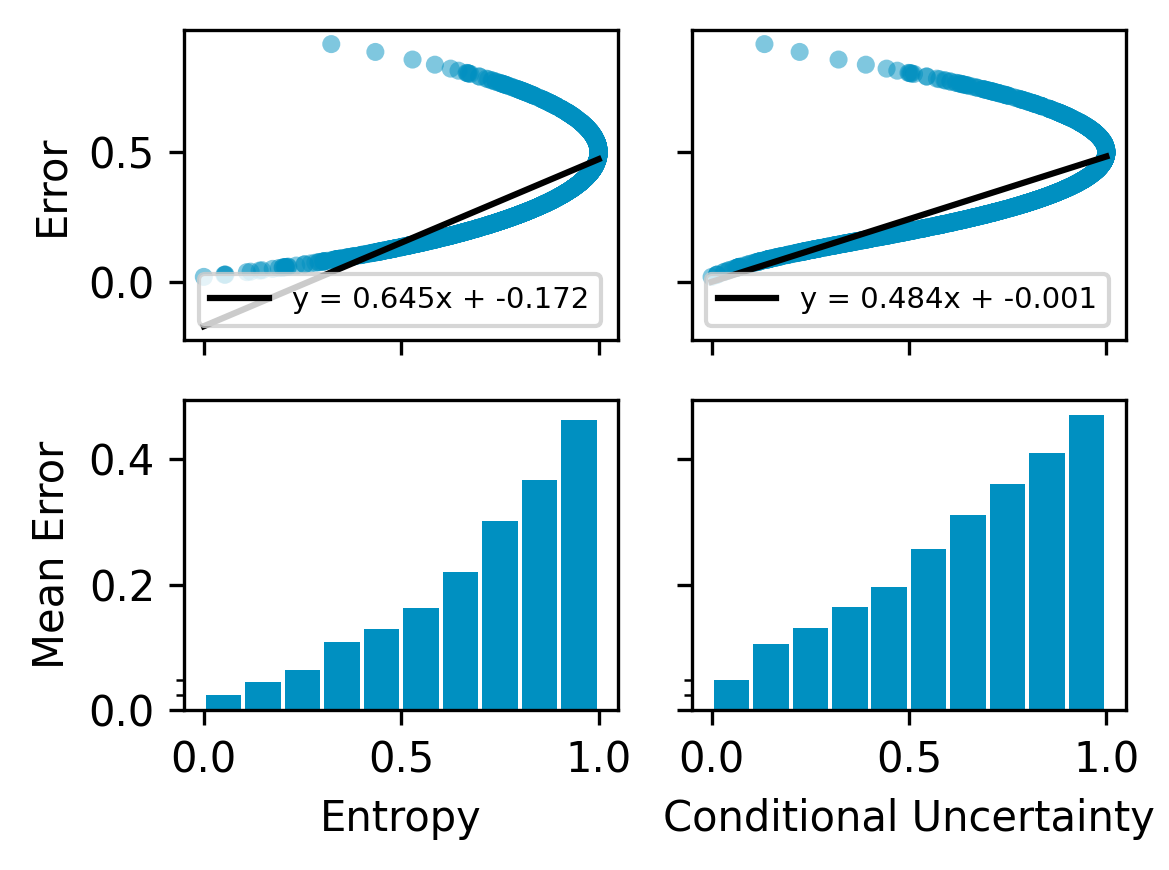

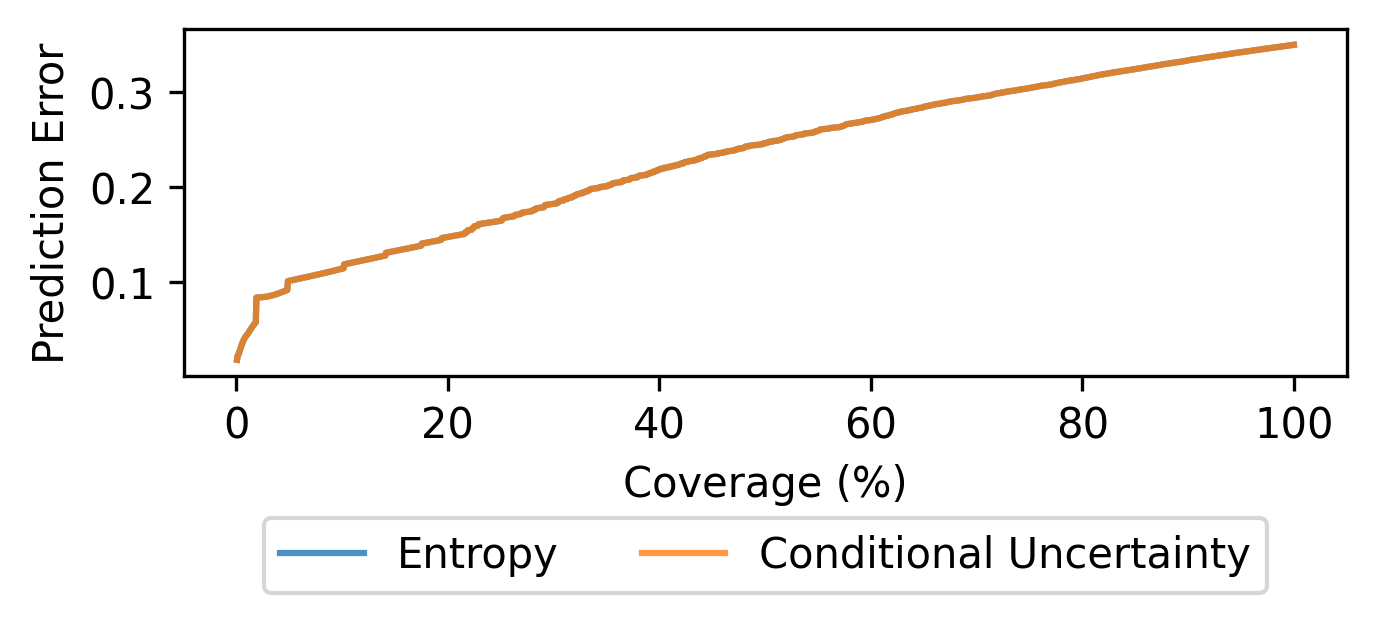

In [62]:
stat_dict = {
    "Entropy":{"ue":"entropy", "loss":"incorrect_class_prob"},
    "Conditional Uncertainty":{"ue":"uncertainty_prob", "loss":"incorrect_class_prob"}
}
survey_pred_dict = get_survey_information(
    model=clf_wo_pc, pred_dict=pred_dict_wo_pc, 
    feat_cols=best_feat_wo_pc_oversampled, 
    target_col=target_col, 
    stat_dict=stat_dict
)

In [65]:
survey_pred_dict["train_df"].iloc[:, -25:-10]

,smoke_ex(1),smoke_current(2),lung cancer_pred,entropy,uncertainty_prob,uncertainty_prob_lb,uncertainty_prob_ub,incorrect_class_prob,lung cancer_pred_label,split,SBP_shap,DBP_shap,dash_shap,BMI_shap,pgs000721_shap
serno,,,,,,,,,,,,,,,
32103,0.0,1.0,0.651351,0.932856,0.417773,0.190832,0.644714,0.651351,1.0,Train,-0.034306,-0.008733,0.009798,-0.021229,-0.044224
39796,0.0,0.0,0.075884,0.387508,0.099853,-0.044055,0.243761,0.075884,0.0,Train,0.038055,0.006843,0.014127,0.016409,0.021836
39853,0.0,1.0,0.598307,0.971932,0.446279,0.219198,0.673361,0.598307,1.0,Train,-0.021988,-0.012126,-0.005062,-0.014109,0.009974
47860,0.0,0.0,0.095494,0.454548,0.122111,-0.040231,0.284452,0.095494,0.0,Train,-0.000164,-0.003035,0.009506,0.059492,0.011819
62061,0.0,0.0,0.247052,0.806571,0.326343,0.101652,0.551035,0.247052,0.0,Train,-0.019770,0.012869,-0.006396,0.028215,-0.015676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43701,0.0,0.0,0.663939,0.920999,0.409133,0.182260,0.636005,0.336061,1.0,Train,0.009102,-0.001461,0.004040,0.023373,0.045417
38273,1.0,0.0,0.696818,0.885146,0.383046,0.156498,0.609593,0.303182,1.0,Train,0.016065,0.012474,0.010575,-0.004101,-0.016258
48777,0.0,1.0,0.905514,0.451268,0.120894,-0.040533,0.282321,0.094486,1.0,Train,0.024826,0.005860,0.021146,0.026936,0.011773


In [37]:
joblib.dump(survey_pred_dict, "truncated_survey_pred_dict.joblib")

['truncated_survey_pred_dict.joblib']

In [70]:
# survey_pred_dict = joblib.load("truncated_survey_pred_dict.joblib")
survey_pred_dict["test_df"]["uncertainty_prob"].describe()

count    1747.000000
mean        0.352110
std         0.106266
min         0.051794
25%         0.277102
50%         0.383707
75%         0.444396
max         0.466770
Name: uncertainty_prob, dtype: float64

In [70]:
old_survey_pred_dict = joblib.load("survey_pred_dict.joblib")
old_survey_pred_dict["val_df"]["uncertainty_prob"].describe()

count    2069.000000
mean        0.375099
std         0.101663
min        -0.147205
25%         0.326581
50%         0.412978
75%         0.449794
max         0.461902
Name: uncertainty_prob, dtype: float64

In [71]:
def select_survey_information(
    survey_pred_dict, selection_list, feat_cols, target_col, scaler, continuous_feats, df_name="test_df"):
    shap_cols = [f"{col}_shap" for col in feat_cols]
    pred_label_col = f"{target_col}_pred_label"
    uncertainty_col = "uncertainty_prob"
    lb_col, ub_col = "uncertainty_prob_lb", "uncertainty_prob_ub"
    correct_col = "correct"
    important_cols = (
        list(feat_cols) + shap_cols + 
        [target_col, pred_label_col, correct_col, uncertainty_col, lb_col, ub_col]
    )
    df = survey_pred_dict[df_name]
    df = df.copy()   
    df[continuous_feats] = scaler.inverse_transform(df[continuous_feats].values)
    df[correct_col] = df[target_col] == df[pred_label_col]
    all_selected_rows = []
    for selection_dict in selection_list:
        # Select class
        cur_df = df[df[target_col] == selection_dict["target_col"]]
        # Select prediction outcome
        cur_df = cur_df.loc[df[correct_col] == selection_dict["correct"]]
        # Select certainty
        selection_fn = selection_dict["uncertainty_selection_fn"]
        selected_uncertainty = selection_fn(cur_df[uncertainty_col])
        selected_row = cur_df[cur_df[uncertainty_col]==selected_uncertainty].head(1)
        all_selected_rows.append(selected_row)
    output_df = pd.concat(all_selected_rows)
    replacement_dict = {1:"Cancer", 0:"Normal"}
    output_df[pred_label_col] = output_df[pred_label_col].astype(int)
    output_df[pred_label_col] = output_df[pred_label_col].replace(replacement_dict)
    output_df[target_col] = output_df[target_col].replace(replacement_dict)
    output_df.loc[output_df["uncertainty_prob_lb"]<0, "uncertainty_prob_lb"] = 0
    return output_df[important_cols]

selection_list = [
    {"target_col": 1, "correct": True, "uncertainty_selection_fn": min}, # Cancer, Correct, Certain
    {"target_col": 1, "correct": False, "uncertainty_selection_fn": max}, # Cancer, Incorrect, Uncertain
    {"target_col": 0, "correct": True, "uncertainty_selection_fn": min}, # Normal, Correct, Certain
    {"target_col": 0, "correct": False, "uncertainty_selection_fn": max}, # Normal, Incorrect, Uncertain
]
selected_df = select_survey_information(
    survey_pred_dict, selection_list, 
    feat_cols=best_feat_wo_pc_oversampled, target_col=target_col, 
    scaler=scaler, continuous_feats = continuous_cols, df_name="test_df"
)
selected_df

,SBP,DBP,dash,BMI,pgs000721,pgs000070,amed,Leisure screen time,age_interview,smoke_current(2),...,ahei2010score_shap,smoke_ex(1)_shap,prevalent diabetes_shap,telomere length_shap,lung cancer,lung cancer_pred_label,correct,uncertainty_prob,uncertainty_prob_lb,uncertainty_prob_ub
serno,,,,,,,,,,,,,,,,,,,,,
84191,131.0,73.0,21.0,22.97445,1.572556,1.166501,3.0,1.5,60.12320,1.0,...,0.019802,-0.005834,0.000475,-0.011503,Cancer,Cancer,True,0.234072,0.021095,0.447050
65593,127.0,87.0,19.0,24.09297,-0.484361,0.793158,2.0,3.5,50.91855,1.0,...,-0.021564,0.005691,-0.000170,0.034524,Cancer,Normal,False,0.465136,0.238010,0.692262
53924,112.0,67.0,23.0,26.77593,0.471336,0.186425,4.0,3.5,47.71800,0.0,...,0.021958,0.004938,-0.000285,0.028805,Normal,Normal,True,0.051794,0.000000,0.140977
14354,194.0,116.0,19.0,22.48273,1.420850,0.960344,4.0,3.5,63.06366,0.0,...,0.018319,-0.009472,0.002866,-0.018996,Normal,Cancer,False,0.466770,0.239641,0.693899


In [72]:
best_feat_wo_pc_oversampled

array(['SBP', 'DBP', 'dash', 'BMI', 'pgs000721', 'pgs000070', 'amed',
       'Leisure screen time', 'age_interview', 'smoke_current(2)',
       'sex (0=Male, 1=Female)', 'ahei2010score', 'smoke_ex(1)',
       'prevalent diabetes', 'telomere length'], dtype=object)

Index: 84191


,Feature,Value
0,Systolic blood pressure (SBP),131.0
1,Diastolic blood pressure (DBP),73.0
2,DASH Diet Score (DASH),21.0
3,Body mass index (BMI),22.97445
4,PGS000721,1.572556
5,PGS000070,1.166501
6,aMED Diet Score (aMED),3.0
7,Leisure screen time (LST),1.5
8,Age,60.1232
9,Current Smoker?,Yes


Prediction: Cancer
Uncertainty
Score: 23.4%
Bounds: 2.1-44.7%


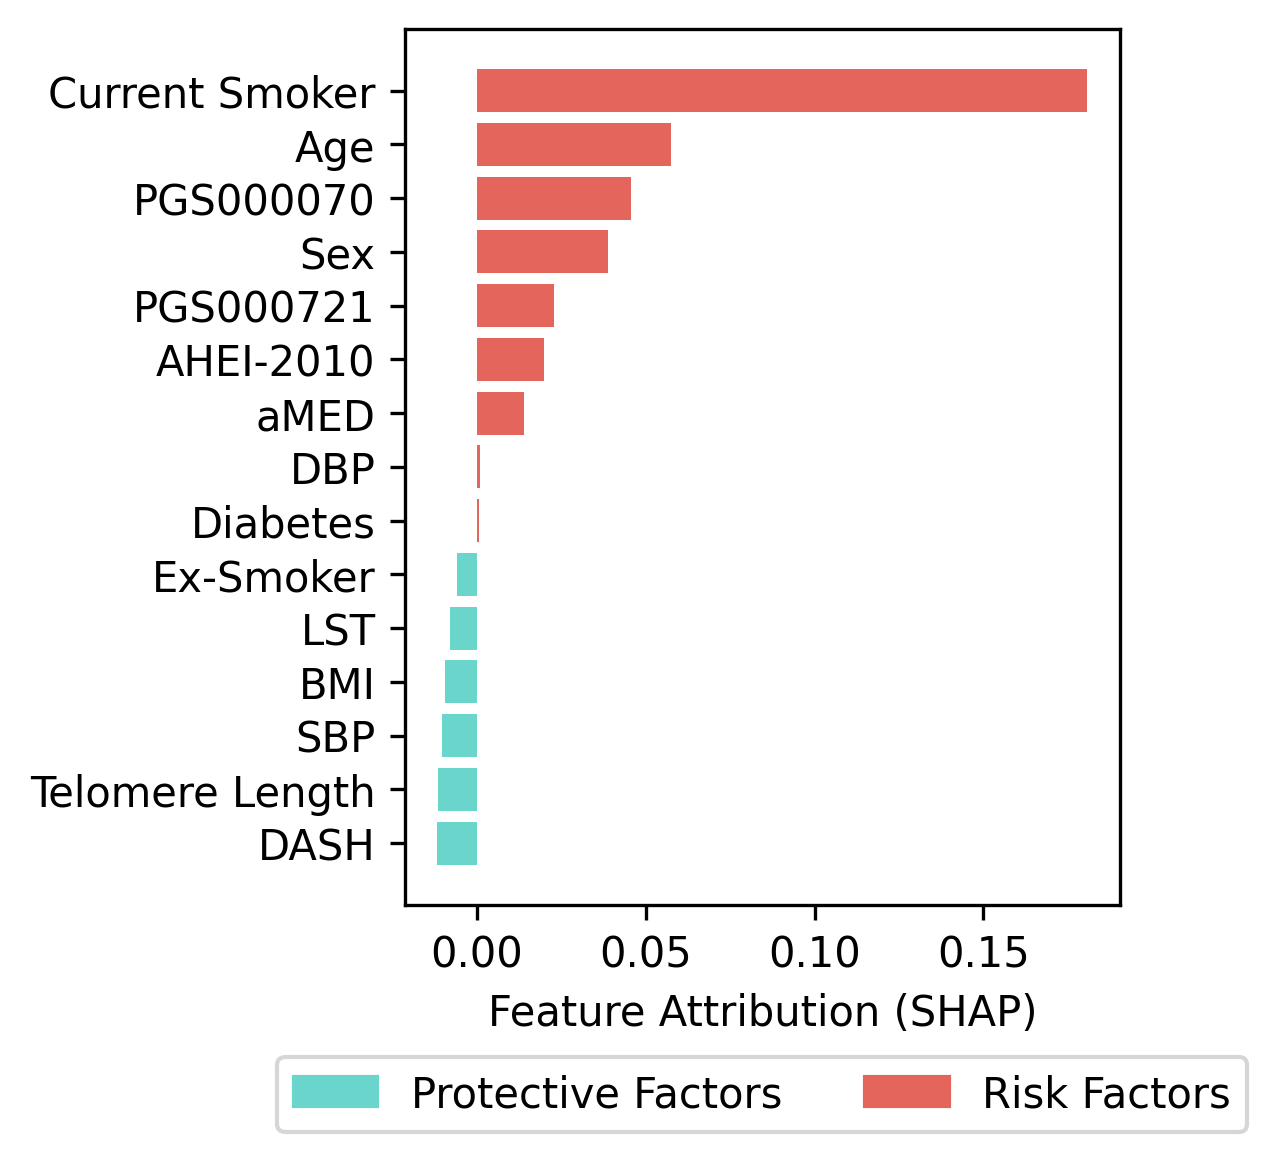


Index: 65593


,Feature,Value
0,Systolic blood pressure (SBP),127.0
1,Diastolic blood pressure (DBP),87.0
2,DASH Diet Score (DASH),19.0
3,Body mass index (BMI),24.09297
4,PGS000721,-0.484361
5,PGS000070,0.793158
6,aMED Diet Score (aMED),2.0
7,Leisure screen time (LST),3.5
8,Age,50.91855
9,Current Smoker?,Yes


Prediction: Normal
Uncertainty
Score: 46.5%
Bounds: 23.8-69.2%


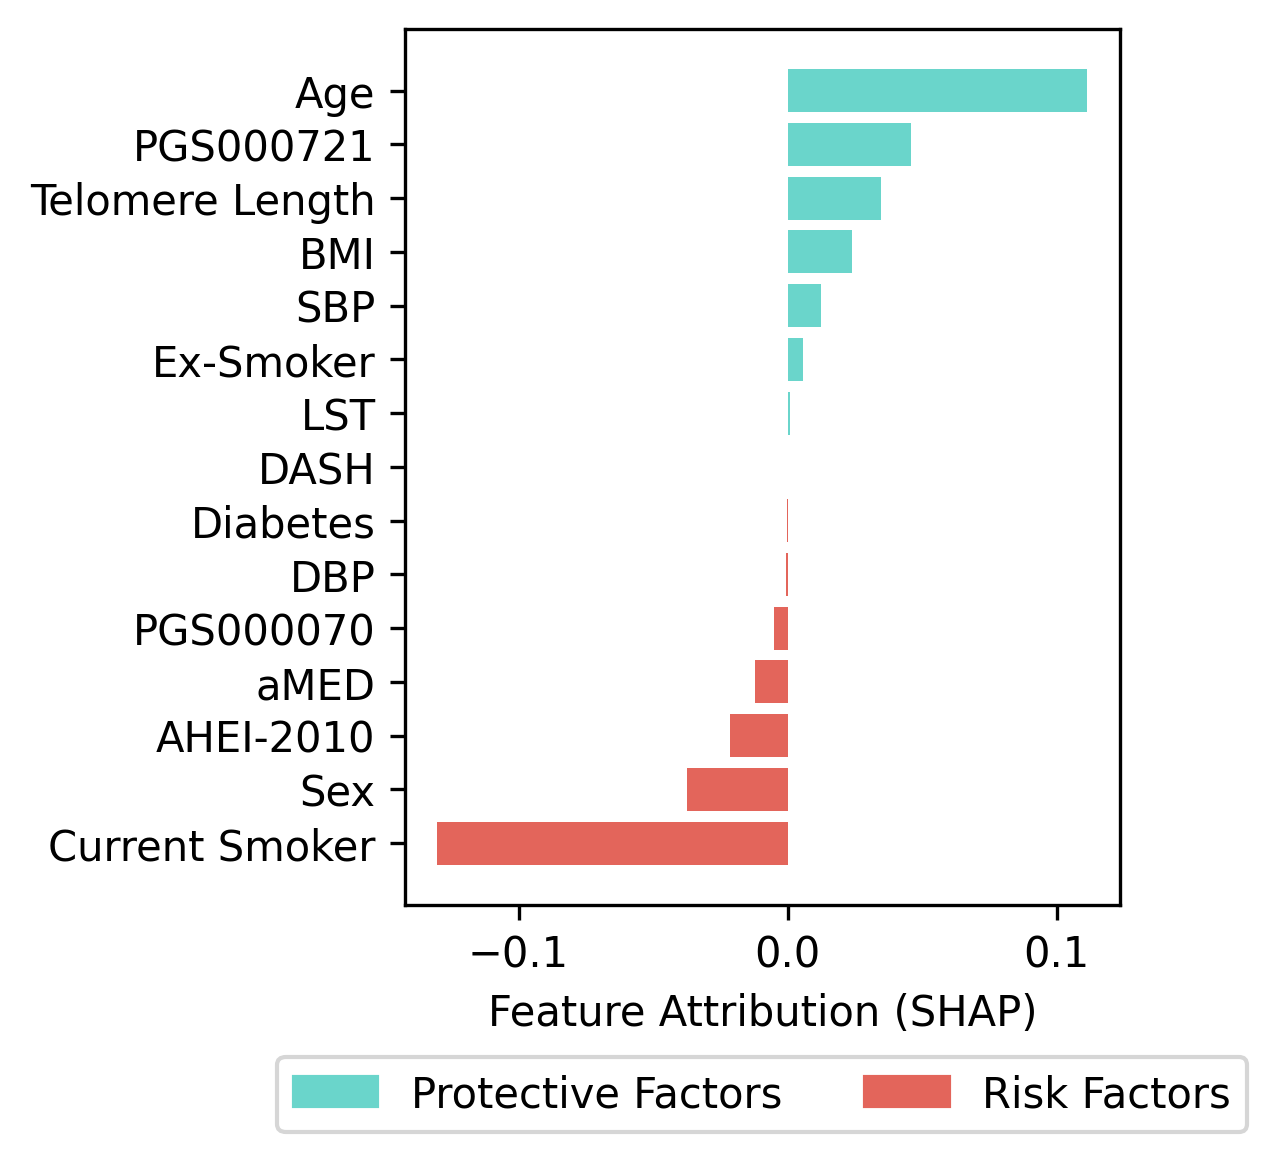


Index: 53924


,Feature,Value
0,Systolic blood pressure (SBP),112.0
1,Diastolic blood pressure (DBP),67.0
2,DASH Diet Score (DASH),23.0
3,Body mass index (BMI),26.77593
4,PGS000721,0.471336
5,PGS000070,0.186425
6,aMED Diet Score (aMED),4.0
7,Leisure screen time (LST),3.5
8,Age,47.718
9,Current Smoker?,No


Prediction: Normal
Uncertainty
Score: 5.2%
Bounds: 0.0-14.1%


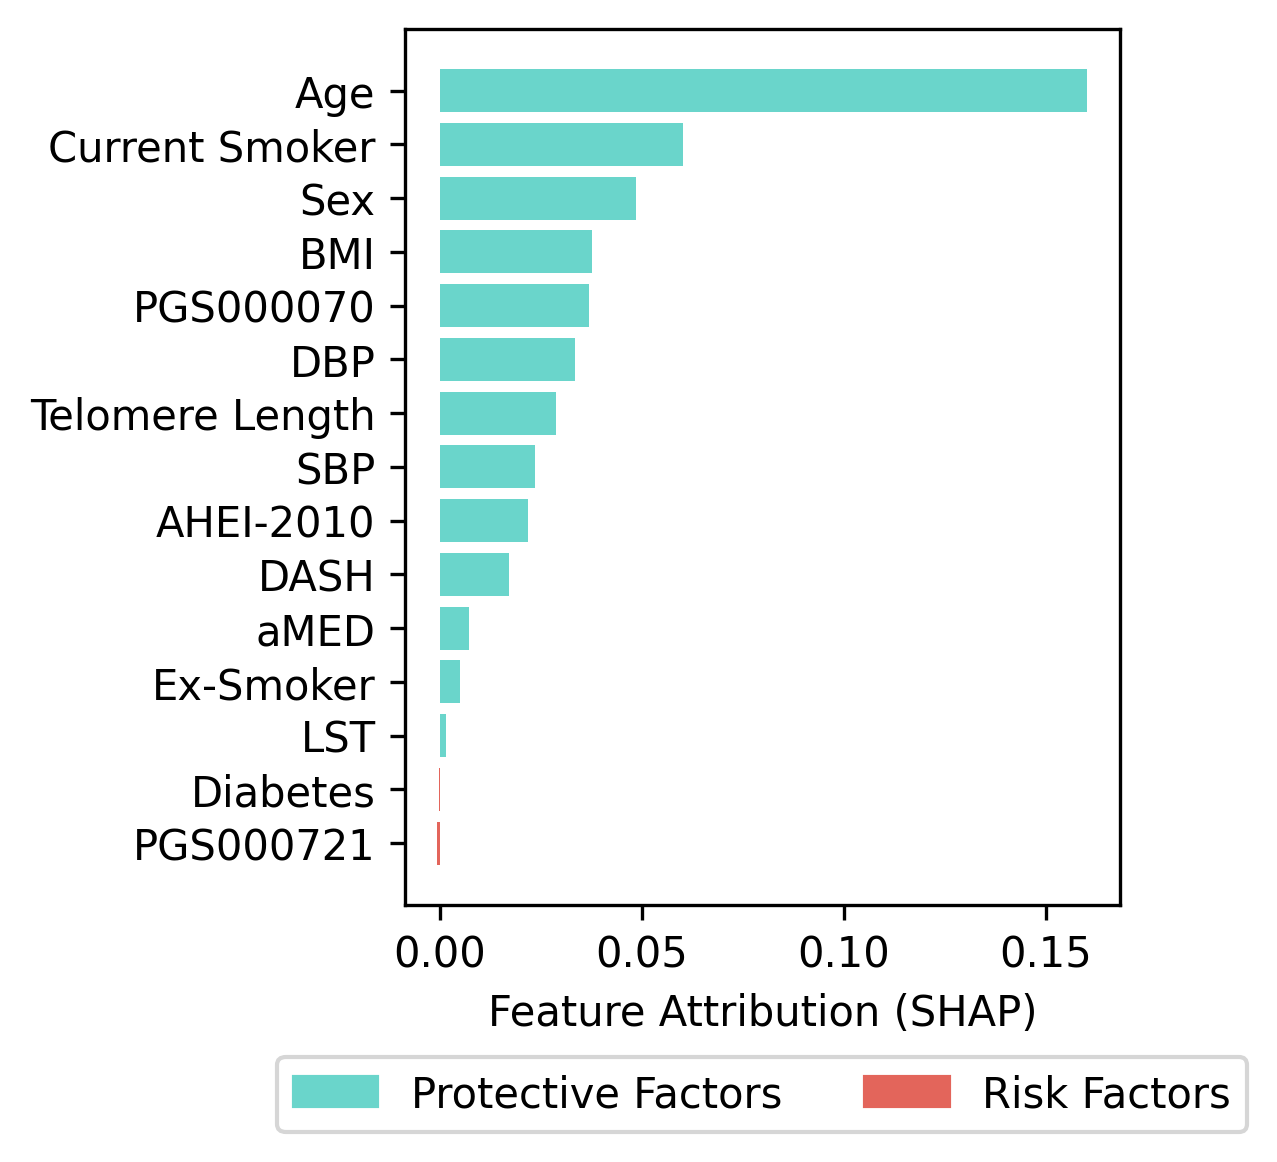


Index: 14354


,Feature,Value
0,Systolic blood pressure (SBP),194.0
1,Diastolic blood pressure (DBP),116.0
2,DASH Diet Score (DASH),19.0
3,Body mass index (BMI),22.48273
4,PGS000721,1.42085
5,PGS000070,0.960344
6,aMED Diet Score (aMED),4.0
7,Leisure screen time (LST),3.5
8,Age,63.06366
9,Current Smoker?,No


Prediction: Cancer
Uncertainty
Score: 46.7%
Bounds: 24.0-69.4%


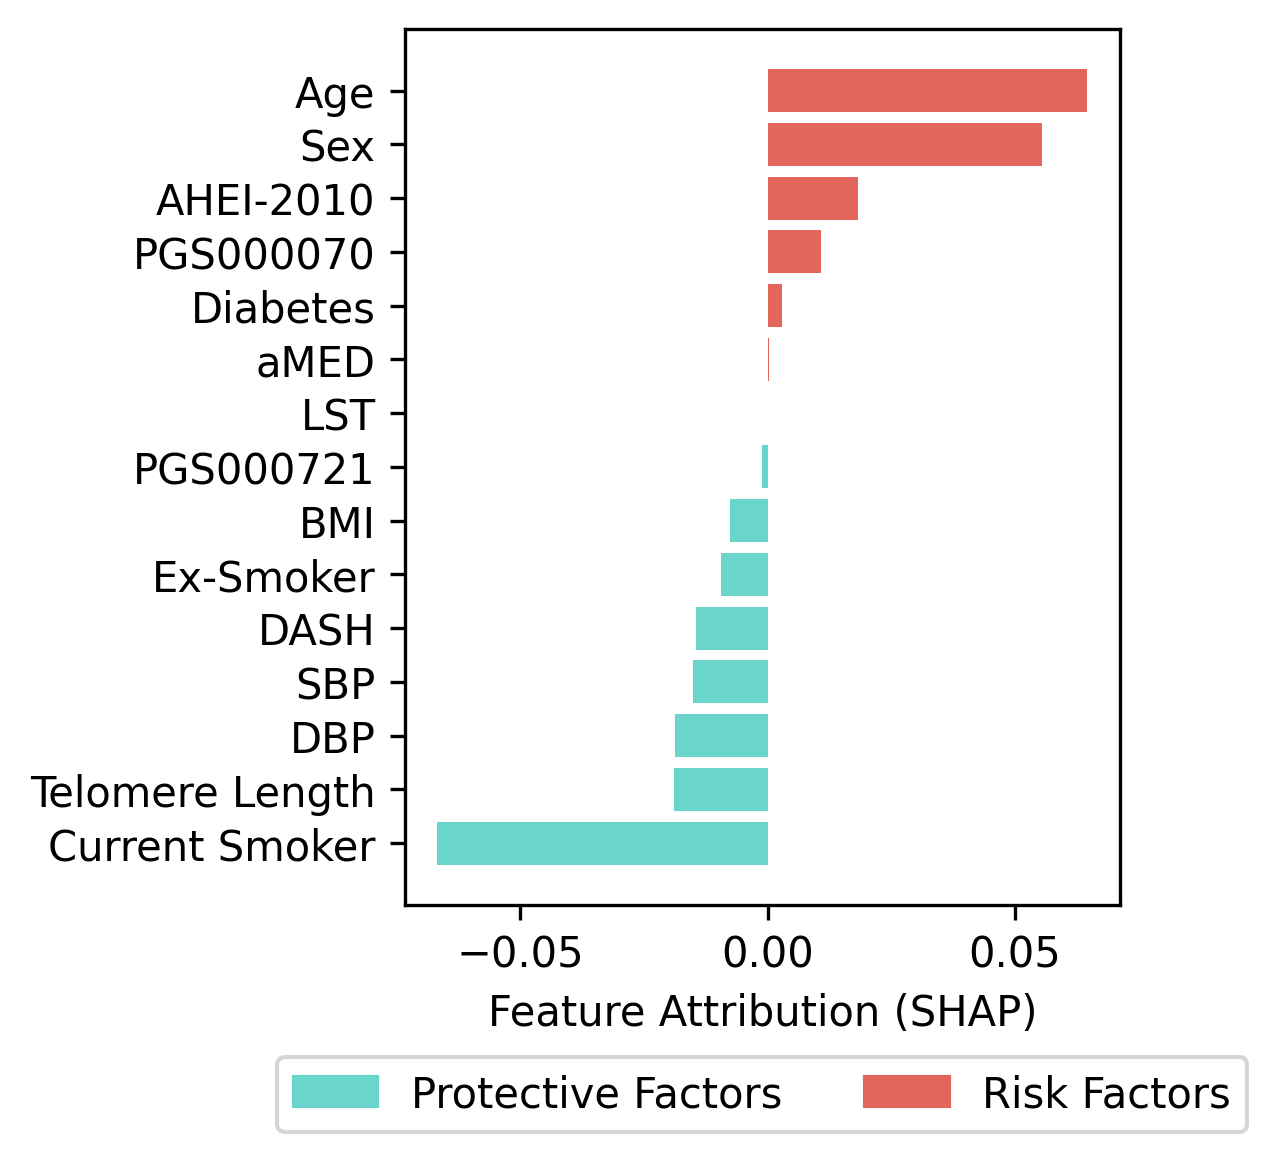

In [78]:
def display_survey_questions(selected_df, feat_cols, clean_feats, clean_shap_feats, target_col):
    pred_col = f"{target_col}_pred_label"
    uncertainty_col = "uncertainty_prob"
    lb_col, ub_col = "uncertainty_prob_lb", "uncertainty_prob_ub"
    shap_cols = [col+"_shap" for col in feat_cols]
    def row_to_df(old_feat_cols, new_feat_cols, row):
        feat_values = row[old_feat_cols].values
        return pd.DataFrame({"Feature":new_feat_cols, "Value":feat_values})
        
    for i in range(len(selected_df)):
        # Show patient features
        row = selected_df.iloc[i].copy()
        print("Index:", row.name)
        sex_col = "sex (0=Male, 1=Female)"
        row[sex_col] = "Female" if row[sex_col] == 1 else "Male"
        binary_cols = ['smoke_current(2)', 'smoke_ex(1)', 'prevalent diabetes']
        for col in binary_cols:
            row[col] = "Yes" if row[col] == 1 else "No"
        
        patient_feature_df = row_to_df(feat_cols, clean_feats, row)
        display(patient_feature_df)
        
        # Show prediction
        pred = row[pred_col]
        print("Prediction:", pred)

        # Show uncertainty estimate
        uncertainty_prob = row[uncertainty_col]*100
        lb, ub = row[lb_col]*100, row[ub_col]*100
        print(f"Uncertainty")
        print(f"Score: {uncertainty_prob:.1f}%")
        print(f"Bounds: {lb:.1f}-{ub:.1f}%")

        # Show SHAP
        colors = {
            "Protective Factors": "#6AD5CB",
            "Risk Factors":"#E3655B"
        }
        fig, ax = plt.subplots(1, 1, dpi=300, figsize=(4, 4))
        shap_df = row_to_df(shap_cols, clean_shap_feats, row)
        shap_df = shap_df.sort_values(by="Value")
        if pred=="Normal":
            color_vec = [
                colors["Risk Factors"] if shap < 0 else colors["Protective Factors"] 
                for shap in shap_df["Value"]]
        else:
            color_vec = [
                colors["Protective Factors"] if shap < 0 else colors["Risk Factors"] 
                for shap in shap_df["Value"]]
        ax.barh(shap_df["Feature"], shap_df["Value"], color=color_vec)
        ax.set_xlabel("Feature Attribution (SHAP)")
        labels, handles = [], []
        for label, color in colors.items():
            labels.append(label)
            handles.append(plt.Rectangle((0,0),1,1, color=color))
        plt.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
        plt.tight_layout()
        plt.show()

        print()
        
clean_feats = [
    "Systolic blood pressure (SBP)", "Diastolic blood pressure (DBP)", "DASH Diet Score (DASH)",
    "Body mass index (BMI)", "PGS000721", "PGS000070", "aMED Diet Score (aMED)", "Leisure screen time (LST)", "Age",
    "Current Smoker?", "Sex", "AHEI-2010 Diet Score", "Ex-Smoker?", "Diabetes", "Telomere Length"
]
clean_shap_feats = [
    "SBP", "DBP", "DASH", "BMI", "PGS000721", "PGS000070", "aMED", "LST", "Age", "Current Smoker", "Sex", 
    "AHEI-2010", "Ex-Smoker", "Diabetes", "Telomere Length"]
display_survey_questions(
    selected_df, feat_cols=best_feat_wo_pc_oversampled, target_col=target_col, 
    clean_feats=clean_feats, clean_shap_feats=clean_shap_feats
)